# Coarse Full Waveform Inversion

1. https://www.kaggle.com/competitions/waveform-inversion/code
2. https://www.kaggle.com/code/hanchenwang114/waveform-inversion-kaggle-competition-tutorial/notebook
3. https://arxiv.org/abs/2111.02926

## Imports

In [184]:
import os,sys; sys.path.append(os.getcwd().replace("fwi",""))
from util import get_torch_device_backend
from acoustic_forward_solver import acoustic_forward_solver, FWIPARAMETERS
from gauss_newton_solver import fwi_gn_solver
import chonknoris
import torch
import gpytorch
import lightning 
from matplotlib import pyplot,colors,cm
import os
import glob
import pandas as pd
import numpy as np
import timeit
import neuralop
import time 
import pyKoLesky.cholesky
import qmcpy as qp  # qmcpy==1.6.3rc0
import fastgps # fastgps==0.0.4.1b0
import warnings

## Torch Setup

In [185]:
torch.set_default_dtype(torch.float64)
torch.manual_seed(17)
DEVICE,TORCH_BACKEND = get_torch_device_backend(deviceidx=0)
print("DEVICE = %s"%str(DEVICE))
print("TORCH_BACKEND = %s"%str(TORCH_BACKEND.__name__))
EPS = torch.finfo(torch.get_default_dtype()).eps
EPS

DEVICE = cuda:0
TORCH_BACKEND = torch.cuda


2.220446049250313e-16

## Boilderplate

In [186]:
ROOT = "."
assert os.path.isfile(ROOT+"/fwi.ipynb")

In [187]:
pyplot.style.use('seaborn-v0_8-whitegrid')
COLORS = ["xkcd:"+color[:-1] for color in pd.read_csv(ROOT+"/../xkcd_colors.txt",comment="#",header=None).iloc[:,0].tolist()][::-1]
COLORS[:3] = COLORS[:3][::-1]
LWTHICK = 3
LWTHIN = .05
HIGHLIGHTS = 4

In [188]:
def compute_l2errors(x, xhat):
    x = x.flatten(start_dim=1)
    xhat = xhat.flatten(start_dim=1) 
    diff = x-xhat
    xnorm = torch.linalg.norm(x,dim=1)
    diffnorm = torch.linalg.norm(diff,dim=1) 
    l2rerror = diffnorm/xnorm 
    return l2rerror

In [189]:
class Predictor:
    def __init__(self, pred, outputs_cls):
        self.pred = pred 
        self.outputs_cls = outputs_cls
    def forward_eval(self, xtf):
        with torch.no_grad(), torch.inference_mode():
            outputstf = self.pred(xtf)
        y = self.outputs_cls.backwards(outputstf) 
        return y

## Load Dataset

In [190]:
pname = "RES7"
vtype = "Style_B"
tag = "RELAX_1e+01"
custom_rkhs_v = False
custom_rkhs_w = False
outdir = './data/%s/%s'%(pname,vtype)
assert os.path.isdir(outdir)
p = FWIPARAMETERS[pname]
for _key,_val in p.items():
    print("p['%s'] = %s"%(_key,_val))
print()
_data_split = torch.load(outdir+"/split_train_val.pt",weights_only=True)
_data_nk = torch.load(outdir+"/NK.%s.RKHS_v_%s.RKHS_w_%s.pt"%(tag,"custom" if custom_rkhs_v else "eye","custom" if custom_rkhs_w else "eye"),weights_only=True)
data = {**_data_split,**_data_nk}
for _key,_val in data.items():
    print("data['%s'].shape = %s"%(_key,str(tuple(_val.shape))))
print()
Thetainv_v = torch.load(outdir+"/RKHS_v_%s.pt"%("custom" if custom_rkhs_v else "eye"),weights_only=True)["Thetainv"]
Thetainv_w = torch.load(outdir+"/RKHS_w_%s.pt"%("custom" if custom_rkhs_w else "eye"),weights_only=True)["Thetainv"]
print("Thetainv_v.shape = %s"%str(tuple(Thetainv_v.shape)))
print("Thetainv_w.shape = %s"%str(tuple(Thetainv_w.shape)))

p['name'] = RES7
p['nx'] = 7
p['dx'] = 10
p['nbc'] = 12
p['nt'] = 101
p['dt'] = 0.001
p['freq'] = 35
p['coord_sx'] = [1.0, 17.5, 35.0, 53.0, 70.0]
p['coord_sz'] = [1, 1, 1, 1, 1]

data['velocity'].shape = (1000, 7, 7)
data['wavefield'].shape = (1000, 5, 100, 7)
data['velocity_train'].shape = (800, 7, 7)
data['velocity_val'].shape = (200, 7, 7)
data['wavefield_train'].shape = (800, 5, 100, 7)
data['wavefield_val'].shape = (200, 5, 100, 7)
data['tidxs'].shape = (800,)
data['vidxs'].shape = (200,)
data['vs'].shape = (1000, 51, 7, 7)
data['rmses'].shape = (1000, 51)
data['times'].shape = (51,)
data['relaxations'].shape = (1000, 51)
data['lrs'].shape = (1000, 51)
data['updated'].shape = (1000, 50)
data['Linvs'].shape = (1000, 50, 49, 49)
data['cond_nums'].shape = (1000, 50)
data['l2rerrors'].shape = (1000, 51)
data['v_true'].shape = (1000, 7, 7)
data['w_true'].shape = (1000, 5, 100, 7)

Thetainv_v.shape = (49, 49)
Thetainv_w.shape = (5, 700, 700)


In [191]:
R,Ns,Nt,Nx = data["wavefield"].shape
lti0,lti1 = torch.tril_indices(Nx**2,Nx**2)
eyeNx2 = torch.eye(Nx**2,device=DEVICE)
Nx2r = torch.arange(Nx*Nx)

## Explore Dataset

### Tables

In [192]:
print("L2 relative errors")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    display(pd.DataFrame(data["l2rerrors"]).describe().T.iloc[::5])

L2 relative errors


,count,mean,std,min,25%,50%,75%,max
0,1000.0,8.084552e-02,1.065192e-02,5.897706e-02,7.390346e-02,7.920822e-02,8.595170e-02,1.605118e-01
5,1000.0,2.812164e-02,2.119210e-02,2.791461e-03,1.602648e-02,2.308737e-02,3.273605e-02,1.913488e-01
10,1000.0,7.420822e-03,7.996472e-03,1.859105e-05,2.227424e-03,5.318816e-03,1.018826e-02,8.796184e-02
15,1000.0,7.204213e-04,2.440164e-03,8.610461e-12,1.893506e-06,2.040904e-05,2.746475e-04,3.103318e-02
20,1000.0,3.381156e-05,4.665376e-04,1.066583e-14,9.402906e-12,1.541099e-09,2.828850e-08,9.965407e-03
25,1000.0,7.766116e-07,1.721662e-05,6.503505e-15,3.983672e-14,8.774507e-14,8.129931e-13,4.260230e-04
30,1000.0,5.820838e-11,1.803928e-09,6.344348e-15,3.117324e-14,5.274002e-14,1.069017e-13,5.704172e-08
35,1000.0,1.133821e-13,9.723250e-13,6.306123e-15,3.013115e-14,5.032020e-14,9.519073e-14,3.069554e-11
40,1000.0,8.225775e-14,8.991602e-14,6.306123e-15,3.013115e-14,5.006827e-14,9.401935e-14,7.366771e-13
45,1000.0,8.207641e-14,8.983840e-14,6.306123e-15,3.007731e-14,4.987216e-14,9.381093e-14,7.366771e-13


In [193]:
print("Relaxations")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    display(pd.DataFrame(data["relaxations"]).describe().T.iloc[::5])

Relaxations


,count,mean,std,min,25%,50%,75%,max
0,1000.0,10.000000,0.000000,10.000000,10.000000,10.000000,10.000000,1.000000e+01
5,1000.0,6.503125,5.233870,0.625000,2.500000,5.000000,10.000000,4.000000e+01
10,1000.0,0.436680,0.840456,0.039062,0.156250,0.312500,0.625000,2.000000e+01
15,1000.0,0.040302,0.068385,0.001221,0.009766,0.019531,0.039062,1.250000e+00
20,1000.0,0.012118,0.020785,0.000076,0.001221,0.004883,0.019531,3.125000e-01
25,1000.0,0.007763,0.024022,0.000010,0.000610,0.002441,0.004883,6.250000e-01
30,1000.0,0.094752,0.696415,0.000005,0.002441,0.009766,0.039062,2.000000e+01
35,1000.0,2.925152,22.292353,0.000019,0.019531,0.156250,1.250000,6.400000e+02
40,1000.0,93.537526,713.363874,0.000305,0.625000,5.000000,40.000000,2.048000e+04
45,1000.0,2993.199077,22827.644204,0.004883,20.000000,160.000000,1280.000000,6.553600e+05


In [194]:
print("Learning rates")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    display(pd.DataFrame(data["lrs"]).describe().T.iloc[::5])

Learning rates


,count,mean,std,min,25%,50%,75%,max
0,1000.0,1.000000,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000
5,1000.0,1.474000,0.499573,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,2.000000
10,1000.0,1.795000,0.625593,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,4.000000
15,1000.0,1.518000,0.622948,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,4.000000
20,1000.0,1.196875,0.477542,1.250000e-01,1.000000e+00,1.000000e+00,1.000000e+00,4.000000
25,1000.0,0.639371,0.519270,3.906250e-03,2.500000e-01,5.000000e-01,1.000000e+00,2.000000
30,1000.0,0.153986,0.288944,1.220703e-04,7.812500e-03,3.125000e-02,1.250000e-01,2.000000
35,1000.0,0.023754,0.085671,3.814697e-06,2.441406e-04,1.953125e-03,7.812500e-03,1.000000
40,1000.0,0.001873,0.017173,1.192093e-07,7.629395e-06,6.103516e-05,2.441406e-04,0.500000
45,1000.0,0.000132,0.002066,3.725290e-09,2.384186e-07,1.907349e-06,7.629395e-06,0.062500


### Plots

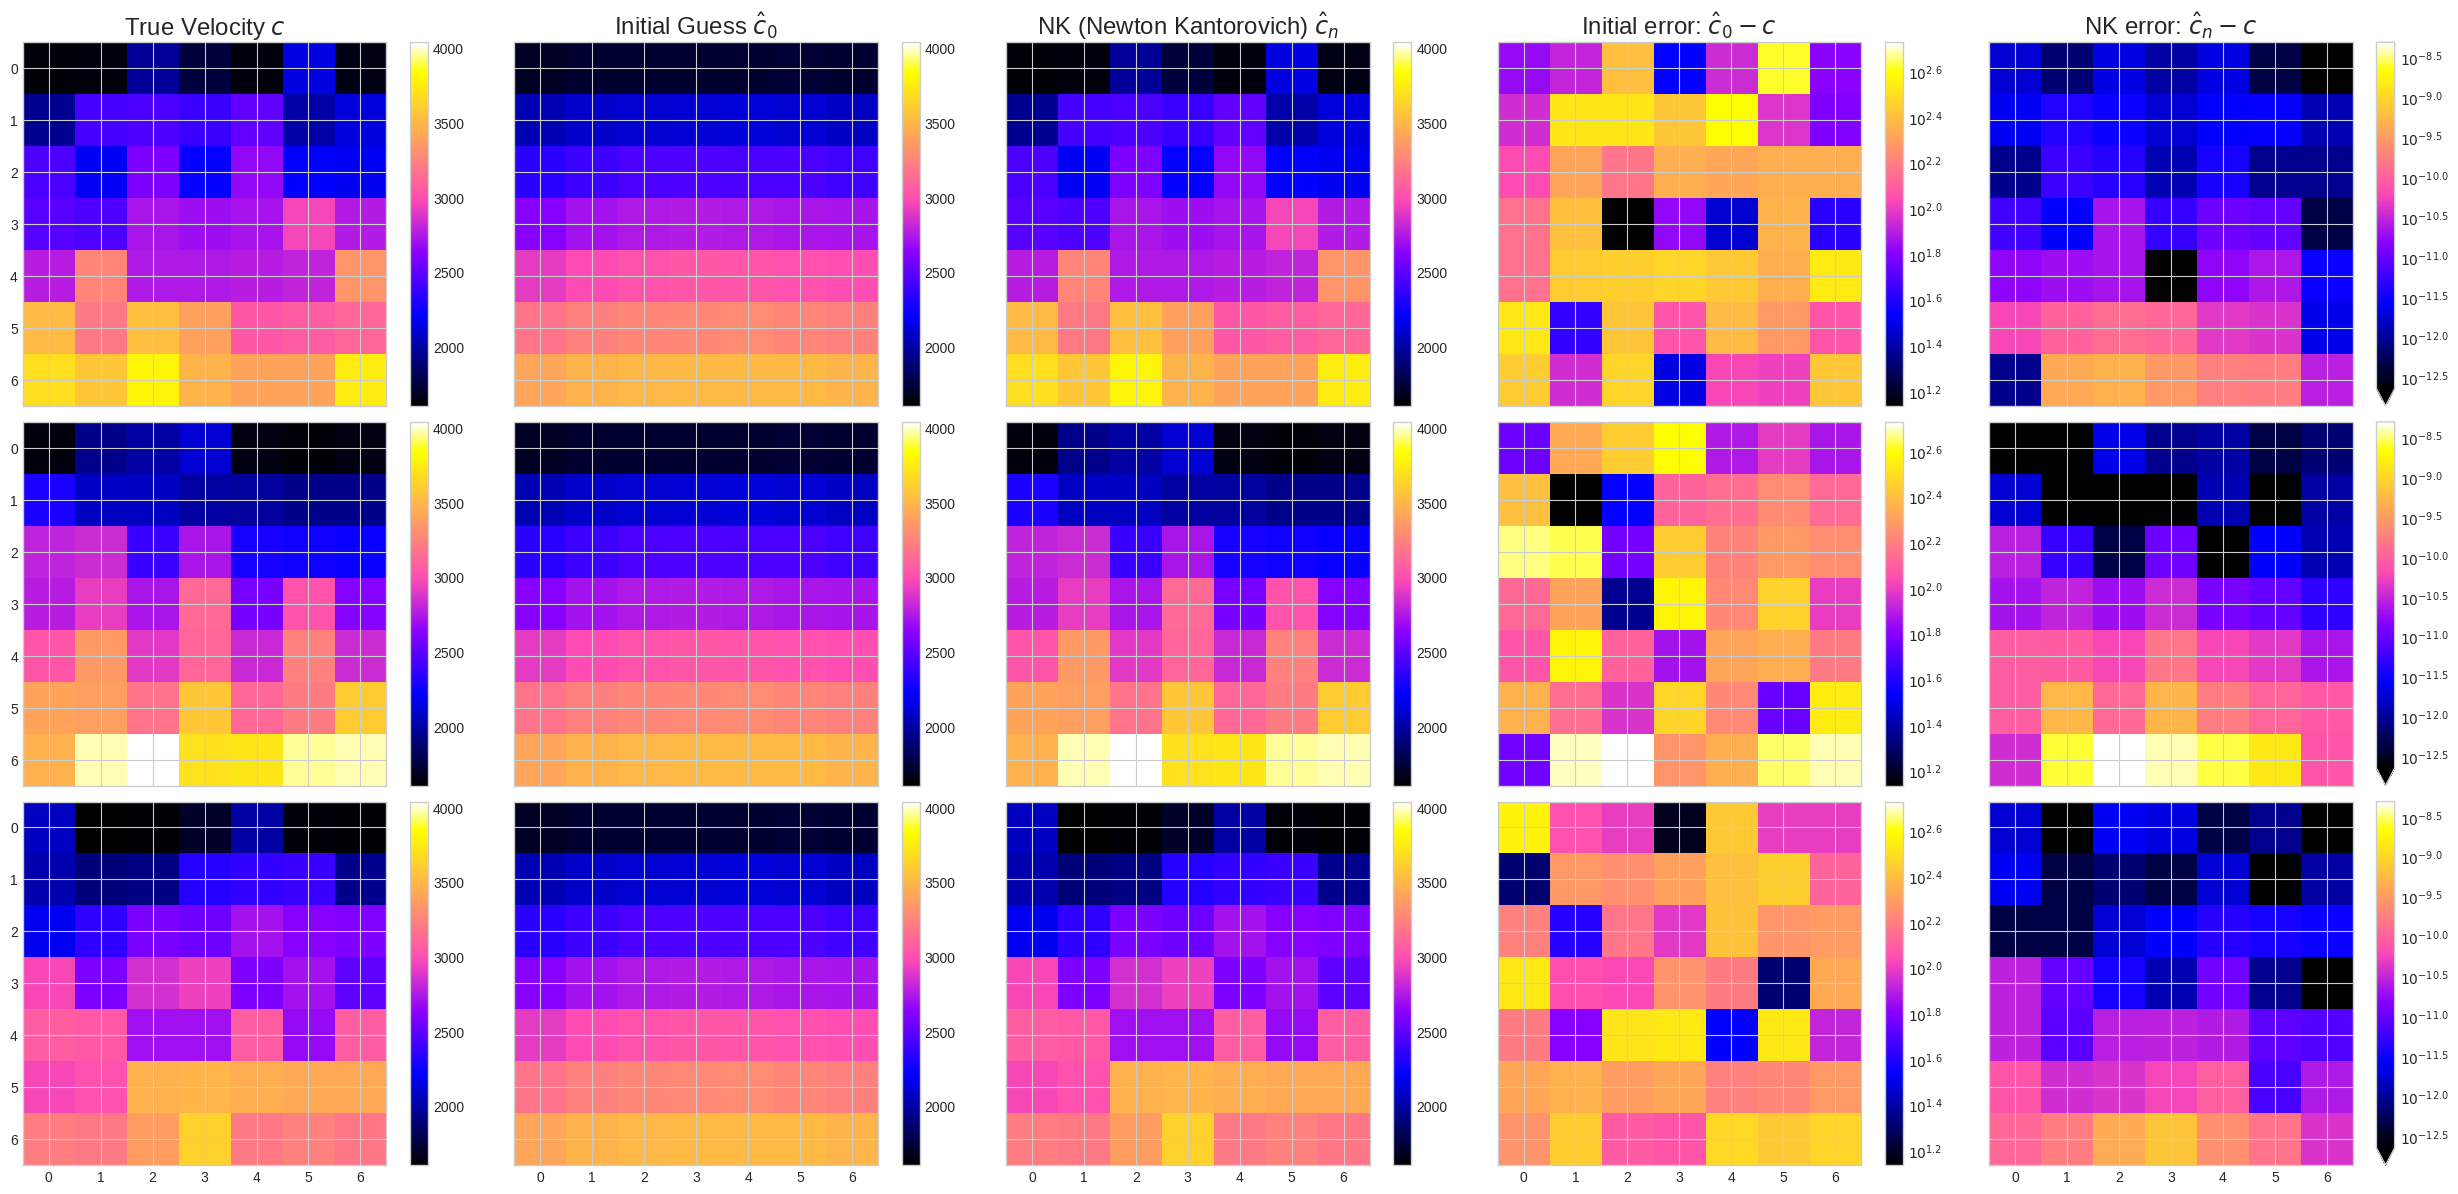

In [195]:
def plot_nk_velocities(v_true, v0, vfinal):
    initial_error_log10 = torch.log10(torch.abs(v_true-v0))
    final_error_log10 = torch.log10(torch.abs(v_true-vfinal))
    final_error_log10[final_error_log10==-torch.inf] = final_error_log10[final_error_log10.isfinite()].min()
    _initial_error_log10_amin = initial_error_log10.min()
    _initial_error_log10_amax = initial_error_log10.max()
    _final_error_log10_amin = final_error_log10.min()
    _final_error_log10_amax = final_error_log10.max()
    _cbmin = torch.min(v_true.min(),v0.min())
    _cbmax = torch.max(v_true.max(),v0.max())
    _plot_data = [
        (v_true,r"True Velocity $c$",_cbmin,_cbmax,False,None),
        (v0,r"Initial Guess $\hat{c}_0$",_cbmin,_cbmax,False,None),
        (vfinal,r"NK (Newton Kantorovich) $\hat{c}_n$",_cbmin,_cbmax,False,None),
        (initial_error_log10,r"Initial error: $\hat{c}_0-c$",_initial_error_log10_amin,_initial_error_log10_amax,True,None),
        (final_error_log10,r"NK error: $\hat{c}_n-c$",_final_error_log10_amin,_final_error_log10_amax,True,"min"),
        ]
    nrows = _plot_data[0][0].size(0)
    ncols = len(_plot_data)
    fig,ax = pyplot.subplots(nrows=nrows,ncols=ncols,figsize=(5*ncols,4*nrows),sharex=True,sharey=True)
    ax = ax.reshape((nrows,ncols))
    for j,(_v,name,_vmin,_vmax,log10ed,extend) in enumerate(_plot_data):
        for i in range(nrows):
            cax = ax[i,j].imshow(_v[i].cpu(),cmap="gnuplot2",vmin=_vmin if _vmin is not None else None,vmax=_vmax if _vmax is not None else None)
            cbar = fig.colorbar(cax,extend=extend)
            if log10ed:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore",UserWarning)
                    cbar.ax.set_yticklabels([r"$10^{%.1f}$"%(int(_tick) if _tick%1==0 else _tick) for _tick in cbar.ax.get_yticks()]) 
        ax[0,j].set_title(name,fontsize="xx-large")
    fig.tight_layout()
    return fig,ax 
_R = 3
fig,ax = plot_nk_velocities(data["velocity"][:_R],data["vs"][:_R,0],data["vs"][:_R,-1])
fig.savefig(outdir+"/fwi_data.png",dpi=256)

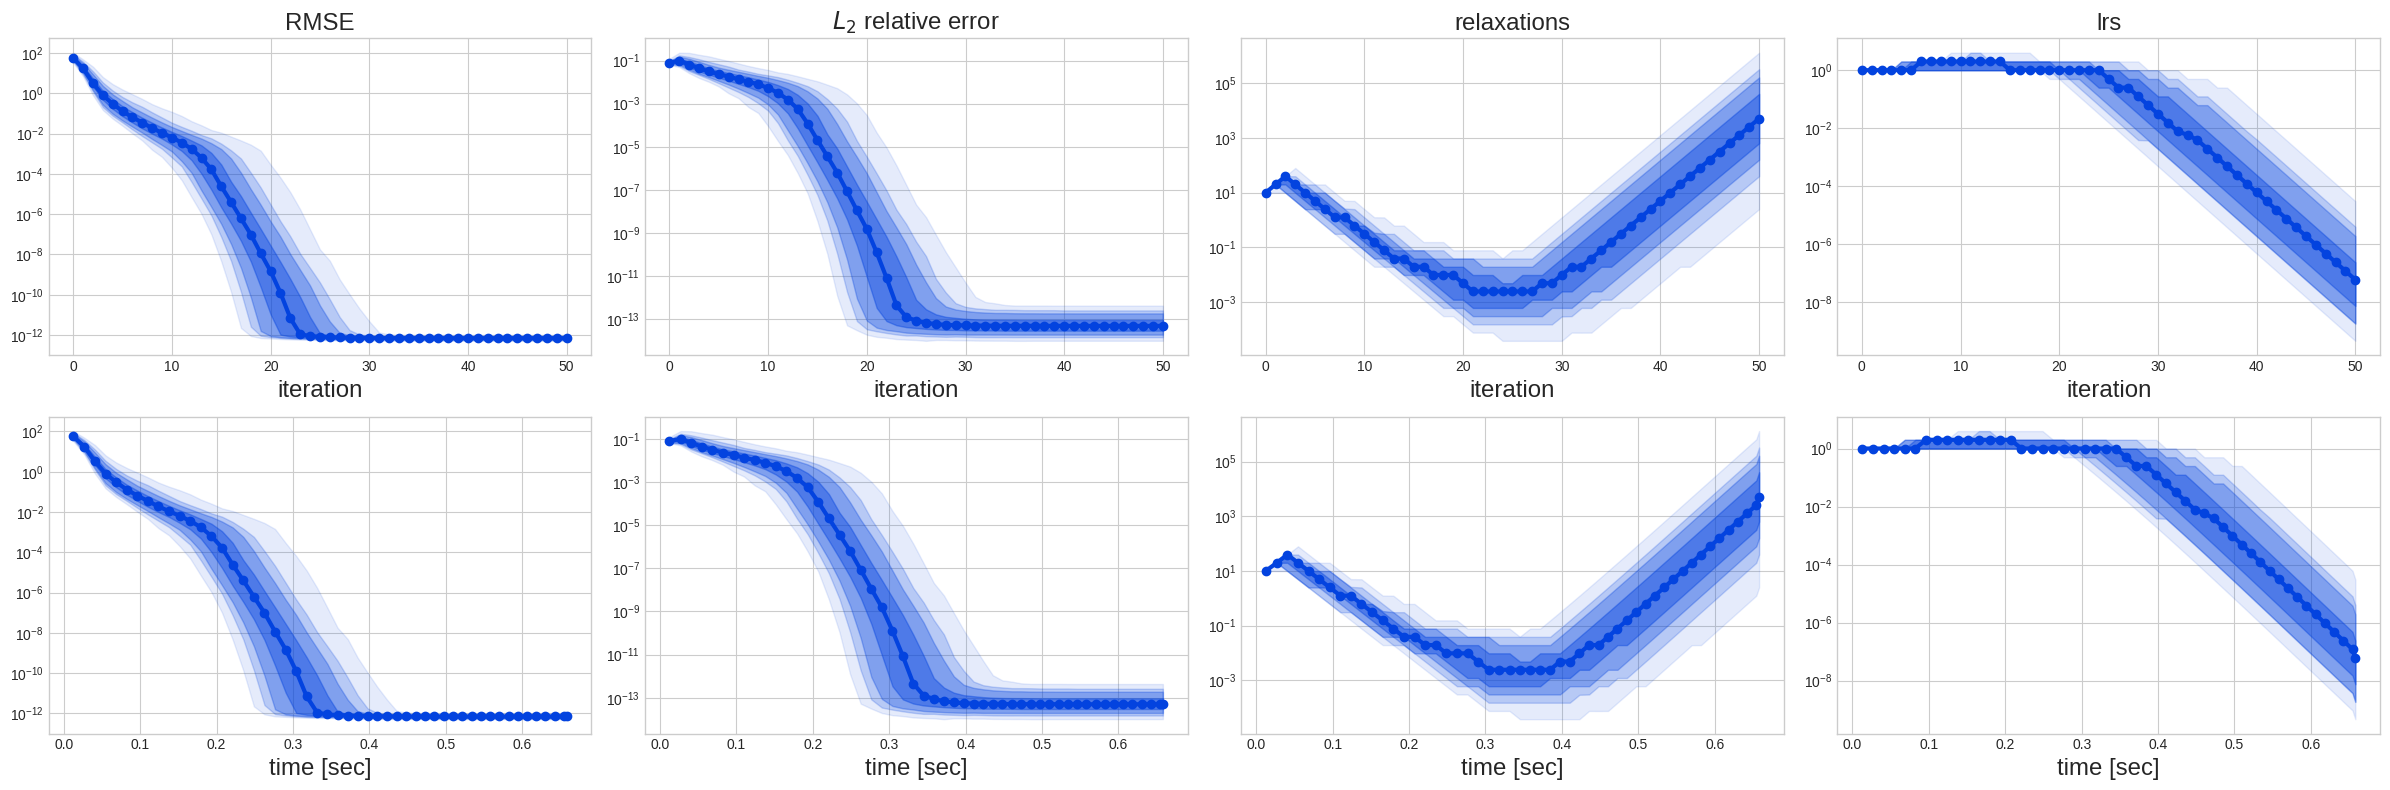

In [196]:
fig,ax = chonknoris.plot_band_strand(
    data = [
        [
            [(None,data["rmses"],None)],
            [(None,data["l2rerrors"],None)],
            [(None,data["relaxations"],None)],
            [(None,data["lrs"],None)],

        ],
        [
            [(data["times"].cumsum(0),data["rmses"],None)],
            [(data["times"].cumsum(0),data["l2rerrors"],None)],
            [(data["times"].cumsum(0),data["relaxations"],None)],
            [(data["times"].cumsum(0),data["lrs"],None)],

        ],
    ],
    sharex = False,
    titles = [["RMSE",r"$L_2$ relative error","relaxations","lrs"],[None,None,None,None]],
    xlabels = [["iteration"],["time [sec]"]],
    xlogscale = False,
    colors = [COLORS[0]],
    ylogscale = True,
    fsx=4,fsy=6,
    legends=False)
fig.tight_layout()
fig.savefig(outdir+"/fwi_coarse_nk_convergence.pdf",bbox_inches="tight")

## Initial Guess Model

### Input Data

In [197]:
class InputDataTFIG:
    def __init__(self, w, tidxs, vidxs, normalize=False):
        self.normalize = normalize
        assert w.device==tidxs.device==vidxs.device
        self.w_t = w[tidxs]
        self.w_v = w[vidxs]
        if self.normalize:
            w_t_mean = self.w_t.mean(0)
            w_t_std = self.w_t.std(0)
            w_t_std[w_t_std==0] = 1
            self.w_t = (self.w_t-w_t_mean)/w_t_std
            self.w_v = (self.w_v-w_t_mean)/w_t_std
        self.w_t = self.w_t.flatten(start_dim=1) 
        self.w_v = self.w_v.flatten(start_dim=1) 
inputs_ig_cls = InputDataTFIG(
    data["wavefield"].to(DEVICE),
    data["tidxs"].to(DEVICE),
    data["vidxs"].to(DEVICE),
    normalize = True,
)
print("inputs_ig_cls.w_t.shape = %s"%str(tuple(inputs_ig_cls.w_t.shape)))
print("inputs_ig_cls.w_v.shape = %s"%str(tuple(inputs_ig_cls.w_v.shape)))

inputs_ig_cls.w_t.shape = (800, 3500)
inputs_ig_cls.w_v.shape = (200, 3500)


### Output Data

In [198]:
class OutputDataTFIG:
    def __init__(self, v, tidxs, vidxs, normalize=False, log=False):
        self.normalize = normalize
        self.log = log
        assert v.device==tidxs.device==vidxs.device
        self.nonbatch_shape = list(v.shape[1:])
        self.v_t = v[tidxs]
        self.v_v = v[vidxs]
        if self.log:
            self.v_t = torch.log(self.v_t)
            self.v_v = torch.log(self.v_v)
        if self.normalize:
            self.v_t_mean = self.v_t.mean(0)
            self.v_t_std = self.v_t.std(0).clone()
            self.v_t_std[self.v_t_std==0] = 1
            self.v_t = (self.v_t-self.v_t_mean)/self.v_t_std
            self.v_v = (self.v_v-self.v_t_mean)/self.v_t_std
        self.v_t = self.v_t.flatten(start_dim=1)
        self.v_v = self.v_v.flatten(start_dim=1)
    def backwards(self, outputs):
        outputs = outputs.reshape([-1]+list(self.nonbatch_shape))
        if self.normalize:
            outputs = outputs*self.v_t_std+self.v_t_mean
        if self.log:
            outputs = torch.exp(outputs)
        return outputs
outputs_ig_cls = OutputDataTFIG(
    data["velocity"].to(DEVICE),
    data["tidxs"].to(DEVICE),
    data["vidxs"].to(DEVICE),
    normalize = True, 
    log = True,
)
print("outputs_ig_cls.v_t.shape = %s"%str(tuple(outputs_ig_cls.v_t.shape)))
print("outputs_ig_cls.v_v.shape = %s"%str(tuple(outputs_ig_cls.v_v.shape)))

outputs_ig_cls.v_t.shape = (800, 49)
outputs_ig_cls.v_v.shape = (200, 49)


### Model Prep

In [199]:
outdir_igmodels = outdir+"/MODELS_IG"
if not os.path.isdir(outdir_igmodels): os.mkdir(outdir_igmodels)

### MLP

In [34]:
import gc
gc.collect()
torch.cuda.empty_cache()

save_dir = outdir_igmodels
name = "MLP"
resume = False

ds_ig_t = chonknoris.DatasetClassic(inputs_ig_cls.w_t.clone(),outputs_ig_cls.v_t.clone())
ds_ig_v = chonknoris.DatasetClassic(inputs_ig_cls.w_v.clone(),outputs_ig_cls.v_v.clone())
print("len(ds_ig_t) = %d"%len(ds_ig_t))
print("len(ds_ig_v) = %d"%len(ds_ig_v))

dl_mlp_ig_t = torch.utils.data.DataLoader(ds_ig_t,batch_size=2**8,collate_fn=tuple,shuffle=True)
dl_mlp_ig_v = torch.utils.data.DataLoader(ds_ig_v,batch_size=len(ds_ig_v),collate_fn=tuple,shuffle=False)
print("len(dl_mlp_t) = %d"%len(dl_mlp_ig_t))
print("len(dl_mlp_v) = %d"%len(dl_mlp_ig_v))
print()

nn_ig = chonknoris.MLP(mlp_layer_nodes=[Ns*Nt*Nx]+5*[Nx*Nx],activation_function=torch.nn.Tanh())
#nn = chonknoris.MLP(mlp_layer_nodes=[1+Nx**2+Ns*Nt*Nx]+5*[1000]+[Nx**2*(1+Nx**2)//2],activation_function=torch.nn.Tanh())
lnn_ig = chonknoris.LightningNN(nn_ig,lr=1e-2,use_l2rerror_loss=True).to(DEVICE)
print(lnn_ig)

csv_logger = lightning.pytorch.loggers.CSVLogger(save_dir=save_dir,name=name,version='csv')
trainer = lightning.Trainer(
    max_epochs = 100,
    logger = [csv_logger],
    #accelerator = "cpu",
    #limit_train_batches=2**10,
    #log_every_n_steps = 1e10,
    enable_progress_bar = True,
    #num_sanity_val_steps = 0,
    #gradient_clip_val = 1.0,
    #gradient_clip_algorithm = "norm",
  )
trainer.fit(
    model = lnn_ig, 
    train_dataloaders = dl_mlp_ig_t,
    val_dataloaders = dl_mlp_ig_v,
    ckpt_path = sorted(glob.glob("./%s/%s/csv/checkpoints/*.ckpt"%(save_dir,name)),key=os.path.getmtime)[-1] if resume else None,
)


Trainer will use only 1 of 7 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=7)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100 80GB PCIe') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
/home/aleksei.sorokin/miniconda3/envs/dno/lib/python3.13/site-packages/lightning/fabric/loggers/csv_logs.py:268: Experiment logs directory ./data/RES7/Style_B/MODELS_IG/MLP/csv exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!
/home/aleksei.sorokin/miniconda3/envs/dno/lib/python3.13/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory ./data/RES7/Style_B/MODELS_IG/MLP/csv/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CU

len(ds_ig_t) = 800
len(ds_ig_v) = 200
len(dl_mlp_t) = 4
len(dl_mlp_v) = 1

LightningNN(
  (nn): MLP(
    (nn_sequential): Sequential(
      (0): Linear(in_features=3500, out_features=49, bias=True)
      (1): Tanh()
      (2): Linear(in_features=49, out_features=49, bias=True)
      (3): Tanh()
      (4): Linear(in_features=49, out_features=49, bias=True)
      (5): Tanh()
      (6): Linear(in_features=49, out_features=49, bias=True)
      (7): Tanh()
      (8): Linear(in_features=49, out_features=49, bias=True)
    )
  )
)
Sanity Checking DataLoader 0:   0%|          | 0/1 [00:00<?, ?it/s]

/home/aleksei.sorokin/miniconda3/envs/dno/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=255` in the `DataLoader` to improve performance.


/home/aleksei.sorokin/miniconda3/envs/dno/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=255` in the `DataLoader` to improve performance.
/home/aleksei.sorokin/miniconda3/envs/dno/lib/python3.13/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (4) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 99: 100%|██████████| 4/4 [00:00<00:00, 67.76it/s, v_num=csv, val_loss=0.811, val_rmse=0.901, val_avg_l2error=6.230, val_avg_l2rerror=0.899, train_loss=0.585, train_rmse=0.765, train_avg_l2error=5.300, train_avg_l2rerror=0.767] 

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 4/4 [00:00<00:00, 22.35it/s, v_num=csv, val_loss=0.811, val_rmse=0.901, val_avg_l2error=6.230, val_avg_l2rerror=0.899, train_loss=0.585, train_rmse=0.765, train_avg_l2error=5.300, train_avg_l2rerror=0.767]


,train_avg_l2error,val_avg_l2error,train_avg_l2rerror,val_avg_l2rerror,train_loss,val_loss,train_rmse,val_rmse
0,6.873765,6.657549,0.990798,0.958156,0.981261,0.920181,0.990430,0.959261
12,6.080228,6.311851,0.879003,0.909321,0.770758,0.830971,0.877891,0.911576
24,5.977509,6.270911,0.863879,0.904465,0.743266,0.820039,0.862087,0.905560
36,5.837447,6.137043,0.844531,0.885546,0.710496,0.782814,0.842885,0.884768
48,5.715052,6.141084,0.826562,0.886976,0.681300,0.782647,0.825380,0.884673
60,5.616444,6.132808,0.812253,0.884388,0.658568,0.785298,0.811499,0.886170
72,5.520480,6.084161,0.799131,0.879498,0.635302,0.769202,0.797012,0.877042
84,5.484526,6.165713,0.793313,0.890184,0.628531,0.794609,0.792787,0.891409
96,5.326702,6.204360,0.771738,0.895406,0.591707,0.804512,0.769176,0.896946


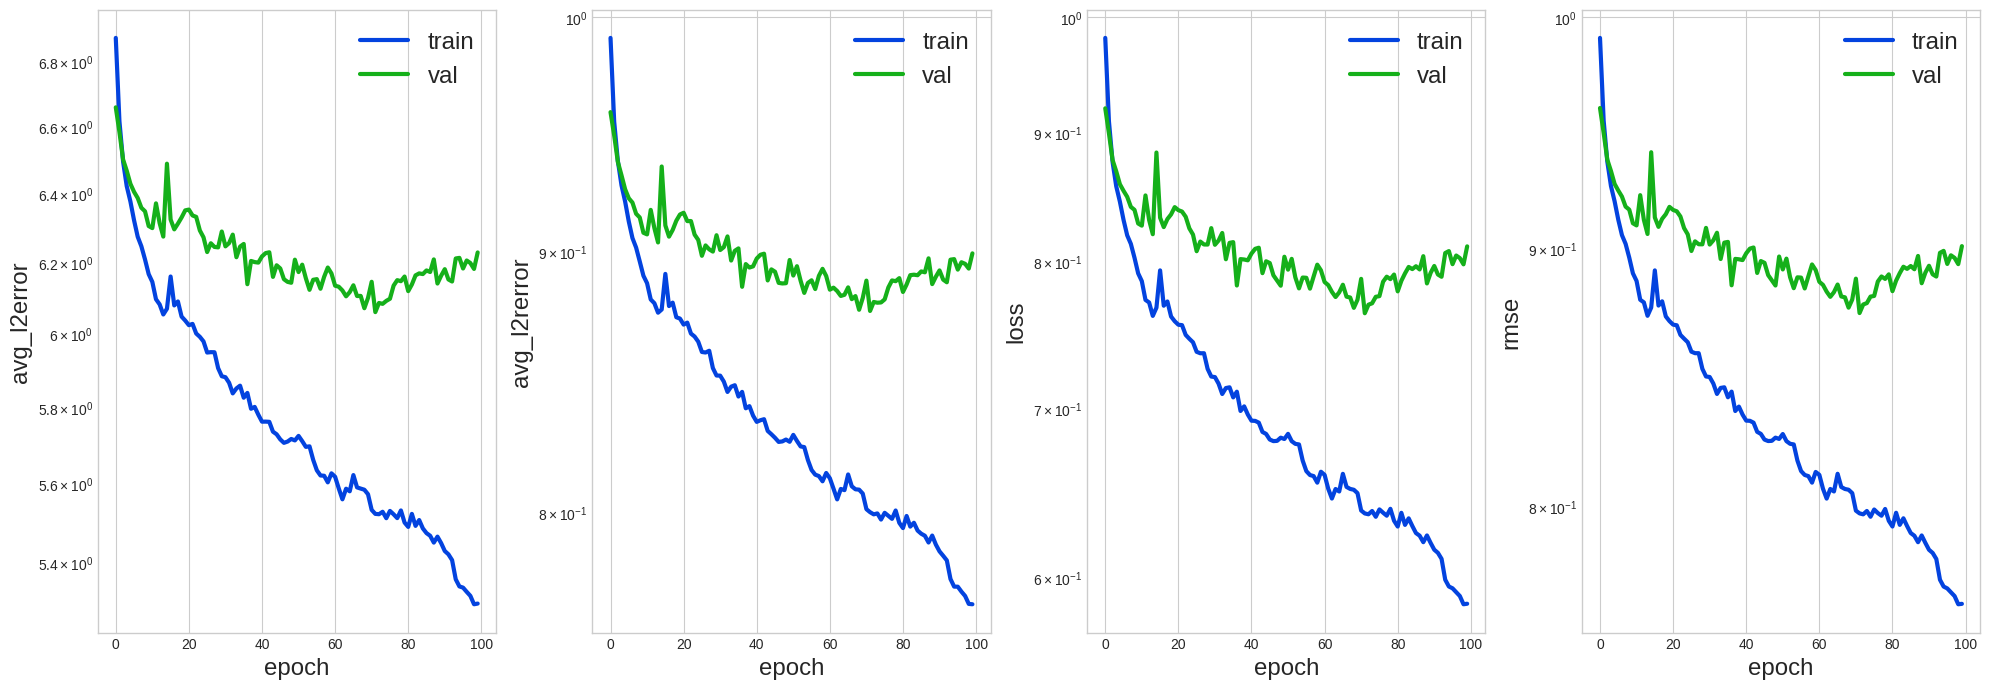

In [35]:
metrics = chonknoris.parse_metrics("%s/%s/csv/metrics.csv"%(save_dir,name))
fig,ax = chonknoris.plot_metrics(metrics,linewidth=LWTHICK,color_train=COLORS[0],color_val=COLORS[1],s0=0)
fig.tight_layout()
metrics.iloc[::max(1,len(metrics)//8)]

In [54]:
mlp_ig_predictor_cls = Predictor(lnn_ig.to(DEVICE), outputs_ig_cls)
vhat_ig_mlp = mlp_ig_predictor_cls.forward_eval(inputs_ig_cls.w_v)
print("l2 relative error: %.2e"%(compute_l2errors(data["velocity_val"].to(DEVICE),vhat_ig_mlp).mean()))

l2 relative error: 7.42e-02


### GP

In [200]:
inputs_ig_cls.w_t.shape,outputs_ig_cls.v_t.T.shape

(torch.Size([800, 3500]), torch.Size([49, 800]))

In [201]:
sgp_ig = fastgps.StandardGP(
    Ns*Nt*Nx,
    data={
        "x": inputs_ig_cls.w_t,
        "y": outputs_ig_cls.v_t.T},
    shape_batch=[Nx*Nx],
    device=DEVICE,
    compile_dist_func=True,
    # scale = 1, 
    # shape_scale = [1],
    shape_scale = [Nx*Nx,1],
    # lengthscales=Ns*Nt*Nx,
    # shape_lengthscales=[1],
    shape_lengthscales=[Ns*Nt*Nx],
    noise=1e-8,
    # shape_noise = [1],
    shape_noise=[Nx*Nx,1],
    requires_grad_noise=True,
    kernel_class="gaussian",
)
for pname,pval in sgp_ig.named_parameters():
    print("%s.shape = %s"%(pname,str(tuple(pval.shape))))
print()
fit_data_sgp_ig = sgp_ig.fit(
    loss_metric="CV",
    cv_weights=1/torch.linalg.norm(data["velocity_train"],dim=(1,2)).to(DEVICE),
    iterations=50,
    verbose=10,
    store_hists=True,
    stop_crit_wait_iterations=np.inf,
    stop_crit_improvement_threshold=1e-1,
    # lr = 1e-6
    #optimizer = torch.optim.Rprop(sgp_ig.parameters(),lr=1e-1,etas=(1/1000,1001/1000),step_sizes=(0,5))
    )

raw_scale.shape = (49, 1)
raw_lengthscales.shape = (3500,)
raw_noise.shape = (49, 1)
raw_factor_task_kernel.shape = (1, 0)
raw_noise_task_kernel.shape = (1,)

     iter of 5.0e+01 | loss       | term1      | term2     
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
            0.00e+00 | 2.04e+00   | nan        | nan       
            1.00e+01 | 1.82e+00   | nan        | nan       
            2.00e+01 | 7.36e-01   | nan        | nan       
            3.00e+01 | 9.29e-01   | nan        | nan       
            4.00e+01 | 7.44e-01   | nan        | nan       
            5.00e+01 | 9.77e-01   | nan        | nan       


dict_keys(['iterations', 'loss_hist', 'scale_hist', 'lengthscales_hist', 'noise_hist', 'task_kernel_hist'])
fit_data_sgp_ig[loss_hist].shape = (51,)
fit_data_sgp_ig[scale_hist].shape = (51, 49, 1)
fit_data_sgp_ig[lengthscales_hist].shape = (51, 3500)
fit_data_sgp_ig[noise_hist].shape = (51, 49, 1)


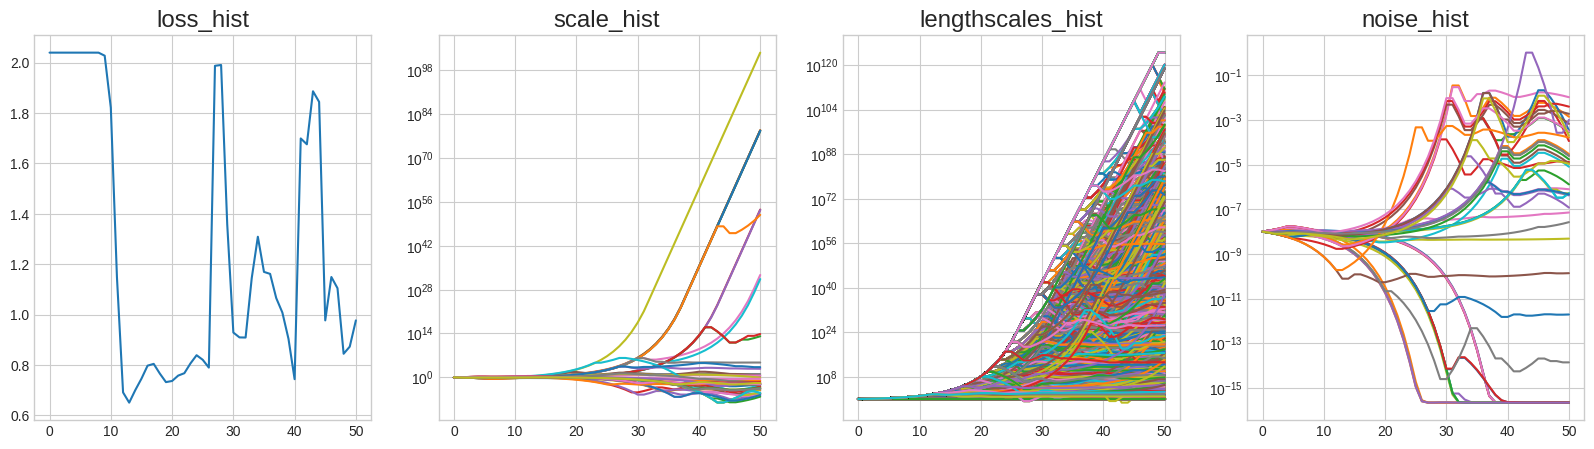

In [202]:
print(fit_data_sgp_ig.keys())
keys_to_plot_log10ed = [
    ('loss_hist',False),
    ('scale_hist',True),
    ('lengthscales_hist',True),
    ('noise_hist',True)]
ncols = len(keys_to_plot_log10ed)
fig,ax = pyplot.subplots(nrows=1,ncols=ncols,figsize=(5*ncols,5))
for i,(key,log10ed) in enumerate(keys_to_plot_log10ed):
    print("fit_data_sgp_ig[%s].shape = %s"%(key,str(tuple(fit_data_sgp_ig[key].shape))))
    if key in ["noise_hist","scale_hist"] and fit_data_sgp_ig[key].ndim==3:
        ax[i].plot(torch.arange(fit_data_sgp_ig[key].size(0)),fit_data_sgp_ig[key][:,:,0])
    else:
        ax[i].plot(torch.arange(fit_data_sgp_ig[key].size(0)),fit_data_sgp_ig[key])
    ax[i].set_title(key,fontsize="xx-large")
    if log10ed: ax[i].set_yscale('log',base=10)

In [203]:
gp_ig_predictor_cls = Predictor(lambda w: sgp_ig.post_mean(w).T, outputs_ig_cls)
vhat_ig_gp = gp_ig_predictor_cls.forward_eval(inputs_ig_cls.w_v)
print("l2 relative error: %.2e"%(compute_l2errors(data["velocity_val"].to(DEVICE),vhat_ig_gp).mean()))

l2 relative error: 5.01e-02


## CHONKNORIS Model

### Input Data

In [214]:
class InputDataTF:
    def __init__(self, relaxation, v, w, tidxs, vidxs, updated, Midxs, normalize=False, log_relaxation=False, log_v=False):
        M = v.size(1) # total number of iterations
        assert (Midxs<(M-1)).all(), "Midxs must be less than M-1=%d"%(M-1)
        self.normalize = normalize
        self.log_relaxation = log_relaxation
        self.log_v = log_v
        assert relaxation.device==v.device==w.device==tidxs.device==vidxs.device==Midxs.device==updated.device
        _updated = updated[:,Midxs]
        updated_t = _updated[tidxs]
        updated_v = _updated[vidxs]
        _vs = v[:,Midxs]
        vs_t = _vs[tidxs][updated_t]
        vs_v = _vs[vidxs][updated_v]
        _relaxations = relaxation[:,Midxs+1]
        relaxations_t = _relaxations[tidxs][updated_t]
        relaxations_v = _relaxations[vidxs][updated_v]
        _wavefield_full = torch.tile(w[:,None,:,:,:],(1,len(Midxs),1,1,1))
        wavefield_full_t = _wavefield_full[tidxs][updated_t]
        wavefield_full_v = _wavefield_full[vidxs][updated_v]
        if self.log_relaxation:
            relaxations_t = torch.log(relaxations_t)
            relaxations_v = torch.log(relaxations_v)
        if self.log_v:
            vs_t = torch.log(vs_t)
            vs_v = torch.log(vs_v)
        self.inputs_t = torch.cat([relaxations_t[:,None],vs_t.flatten(start_dim=1),wavefield_full_t.flatten(start_dim=1)],dim=-1)
        self.inputs_v = torch.cat([relaxations_v[:,None],vs_v.flatten(start_dim=1),wavefield_full_v.flatten(start_dim=1)],dim=-1)
        if self.normalize:
            self.inputs_t_mean = self.inputs_t.mean(0) 
            self.inputs_t_std = self.inputs_t.std(0) 
            self.inputs_t_std[self.inputs_t_std==0] = 1
            self.inputs_t = (self.inputs_t-self.inputs_t_mean)/self.inputs_t_std
            self.inputs_v = (self.inputs_v-self.inputs_t_mean)/self.inputs_t_std
    def forwards(self, relaxation, v, w):
        assert relaxation.ndim==1 and v.ndim>=2 and w.ndim>=2
        assert relaxation.shape[0]==v.shape[0]==w.shape[0]
        if self.log_relaxation:
            relaxation = torch.log(relaxation) 
        if self.log_v:
            v = torch.log(v) 
        inputs = torch.cat([relaxation[...,None],v.flatten(start_dim=1),w.flatten(start_dim=1)],dim=1)
        if self.normalize:
            inputs = (inputs-self.inputs_t_mean)/self.inputs_t_std
        return inputs
Midxs = torch.linspace(1,29,steps=10,dtype=int,device=DEVICE)
#Midxs = torch.linspace(0,10,steps=9,dtype=int,device=DEVICE)
print("Midxs = %s"%str(Midxs.cpu().numpy()))
print("len(Midxs) = %d"%len(Midxs))
inputs_cls = InputDataTF(
    data["relaxations"].to(DEVICE),
    data["vs"].to(DEVICE), 
    data["wavefield"].to(DEVICE),
    data["tidxs"].to(DEVICE),
    data["vidxs"].to(DEVICE),
    data["updated"].to(DEVICE),
    Midxs = Midxs,
    normalize = True, 
    log_relaxation = True, 
    log_v = True,
)
print("inputs_cls.inputs_t.shape = %s"%str(tuple(inputs_cls.inputs_t.shape)))
print("inputs_cls.inputs_v.shape = %s"%str(tuple(inputs_cls.inputs_v.shape)))

Midxs = [ 1  4  7 10 13 16 19 22 25 29]
len(Midxs) = 10
inputs_cls.inputs_t.shape = (7034, 3550)
inputs_cls.inputs_v.shape = (1769, 3550)


### Output Data

In [215]:
class OutputDataTF:
    def __init__(self, L, tidxs, vidxs, updated, Midxs, normalize=False, log_diag=False):
        self.normalize = normalize
        self.log_diag = log_diag 
        assert L.device==tidxs.device==vidxs.device==Midxs.device
        L = L[:,Midxs]
        _updated = updated[:,Midxs].clone()
        updated_t = _updated[tidxs]
        updated_v = _updated[vidxs]
        self.L_t = L[tidxs][updated_t].clone()
        self.L_v = L[vidxs][updated_v]
        L_t = self.L_t.clone()
        L_v = self.L_v.clone()
        if self.log_diag:
            L_t[...,Nx2r,Nx2r] = torch.log(L_t[...,Nx2r,Nx2r])
            L_v[...,Nx2r,Nx2r] = torch.log(L_v[...,Nx2r,Nx2r])
        self.outputs_t = L_t[:,lti0,lti1]
        self.outputs_v = L_v[:,lti0,lti1]
        if self.normalize:
            self.outputs_t_mean = self.outputs_t.mean(0)
            self.outputs_t_std = self.outputs_t.std(0)
            self.outputs_t_std[self.outputs_t_std==0] = 1
            self.outputs_t = (self.outputs_t-self.outputs_t_mean)/self.outputs_t_std
            self.outputs_v = (self.outputs_v-self.outputs_t_mean)/self.outputs_t_std
    def backwards(self, outputs):
        if self.normalize:
            outputs = outputs*self.outputs_t_std+self.outputs_t_mean
        L = torch.zeros(list(outputs.shape[:-1])+[Nx**2,Nx**2],device=outputs.device)
        L[...,lti0,lti1] = outputs
        if self.log_diag:
            L[...,Nx2r,Nx2r] = torch.exp(L[...,Nx2r,Nx2r])
        return L
outputs_cls = OutputDataTF(
    torch.linalg.solve_triangular(data["Linvs"].to(DEVICE),eyeNx2,upper=False),
    data["tidxs"].to(DEVICE),
    data["vidxs"].to(DEVICE),
    data["updated"].to(DEVICE),
    Midxs = Midxs,
    normalize = True, 
    log_diag = True,
)
print("outputs_cls.outputs_t.shape = %s"%str(tuple(outputs_cls.outputs_t.shape)))
print("outputs_cls.outputs_v.shape = %s"%str(tuple(outputs_cls.outputs_v.shape)))

outputs_cls.outputs_t.shape = (7034, 1225)
outputs_cls.outputs_v.shape = (1769, 1225)


### Model Prep

In [216]:
outdir_chonknoris = outdir+"/MODELS_L"
if not os.path.isdir(outdir_chonknoris): os.mkdir(outdir_chonknoris)

## MLP

In [34]:
import gc
gc.collect()
torch.cuda.empty_cache()

save_dir = outdir_chonknoris
name = "MLP"
resume = False

ds_t = chonknoris.DatasetClassic(inputs_cls.inputs_t,outputs_cls.outputs_t)
ds_v = chonknoris.DatasetClassic(inputs_cls.inputs_v,outputs_cls.outputs_v)

dl_mlp_t = torch.utils.data.DataLoader(ds_t,batch_size=2**8,collate_fn=tuple,shuffle=True)
dl_mlp_v = torch.utils.data.DataLoader(ds_v,batch_size=len(ds_v),collate_fn=tuple,shuffle=False)
print("len(dl_mlp_t) = %d"%len(dl_mlp_t))
print("len(dl_mlp_v) = %d"%len(dl_mlp_v))
print()

nn = chonknoris.MLP(mlp_layer_nodes=[1+Nx**2+Ns*Nt*Nx]+3*[250]+[Nx**2*(1+Nx**2)//2],activation_function=torch.nn.Tanh())
#nn = chonknoris.MLP(mlp_layer_nodes=[1+Nx**2+Ns*Nt*Nx]+5*[1000]+[Nx**2*(1+Nx**2)//2],activation_function=torch.nn.Tanh())
lnn = chonknoris.LightningNN(nn,lr=5e-3,use_l2rerror_loss=True).to(DEVICE)
print(lnn)

csv_logger = lightning.pytorch.loggers.CSVLogger(save_dir=save_dir,name=name,version='csv')
trainer = lightning.Trainer(
    max_epochs = 25,
    logger = [csv_logger],
    #accelerator = "cpu",
    #limit_train_batches=2**10,
    #log_every_n_steps = 1e10,
    enable_progress_bar = True,
    #num_sanity_val_steps = 0,
    #gradient_clip_val = 1.0,
    #gradient_clip_algorithm = "norm",
  )
trainer.fit(
    model = lnn, 
    train_dataloaders = dl_mlp_t,
    val_dataloaders = dl_mlp_v,
    ckpt_path = sorted(glob.glob("./%s/%s/csv/checkpoints/*.ckpt"%(save_dir,name)),key=os.path.getmtime)[-1] if resume else None,
)


Trainer will use only 1 of 7 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=7)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100 80GB PCIe') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6]

  | Name | Type | Params | Mo

len(dl_mlp_t) = 6
len(dl_mlp_v) = 1

LightningNN(
  (nn): MLP(
    (nn_sequential): Sequential(
      (0): Linear(in_features=1801, out_features=250, bias=True)
      (1): Tanh()
      (2): Linear(in_features=250, out_features=250, bias=True)
      (3): Tanh()
      (4): Linear(in_features=250, out_features=250, bias=True)
      (5): Tanh()
      (6): Linear(in_features=250, out_features=325, bias=True)
    )
  )
)
                                                                           

/home/aleksei.sorokin/miniconda3/envs/dno/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=255` in the `DataLoader` to improve performance.
/home/aleksei.sorokin/miniconda3/envs/dno/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=255` in the `DataLoader` to improve performance.
/home/aleksei.sorokin/miniconda3/envs/dno/lib/python3.13/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (6) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 24: 100%|██████████| 6/6 [00:00<00:00, 63.06it/s, v_num=csv, val_loss=0.000222, val_rmse=0.0149, val_avg_l2error=0.267, val_avg_l2rerror=0.628, train_loss=0.000316, train_rmse=0.0177, train_avg_l2error=0.317, train_avg_l2rerror=0.742]

`Trainer.fit` stopped: `max_epochs=25` reached.


Epoch 24: 100%|██████████| 6/6 [00:00<00:00, 14.49it/s, v_num=csv, val_loss=0.000222, val_rmse=0.0149, val_avg_l2error=0.267, val_avg_l2rerror=0.628, train_loss=0.000316, train_rmse=0.0177, train_avg_l2error=0.317, train_avg_l2rerror=0.742]


,train_avg_l2error,val_avg_l2error,train_avg_l2rerror,val_avg_l2rerror,train_loss,val_loss,train_rmse,val_rmse
0,4.740791,3.817736,11.196187,9.084856,0.076513,0.044847,0.262984,0.211770
3,1.783735,1.947426,4.214823,4.625743,0.010089,0.011671,0.098945,0.108032
6,0.926905,0.635415,2.185545,1.509857,0.002773,0.001243,0.051426,0.035254
9,0.545992,0.458761,1.285335,1.087575,0.000930,0.000649,0.030309,0.025474
12,0.470748,0.452146,1.105893,1.072825,0.000688,0.000630,0.026149,0.025103
15,0.422407,0.498920,0.991473,1.183349,0.000558,0.000767,0.023474,0.027697
18,0.383728,0.363183,0.899789,0.859037,0.000464,0.000408,0.021339,0.020193
21,0.330114,0.329918,0.772048,0.777910,0.000341,0.000338,0.018395,0.018380
24,0.317038,0.267011,0.741512,0.628109,0.000316,0.000222,0.017679,0.014912


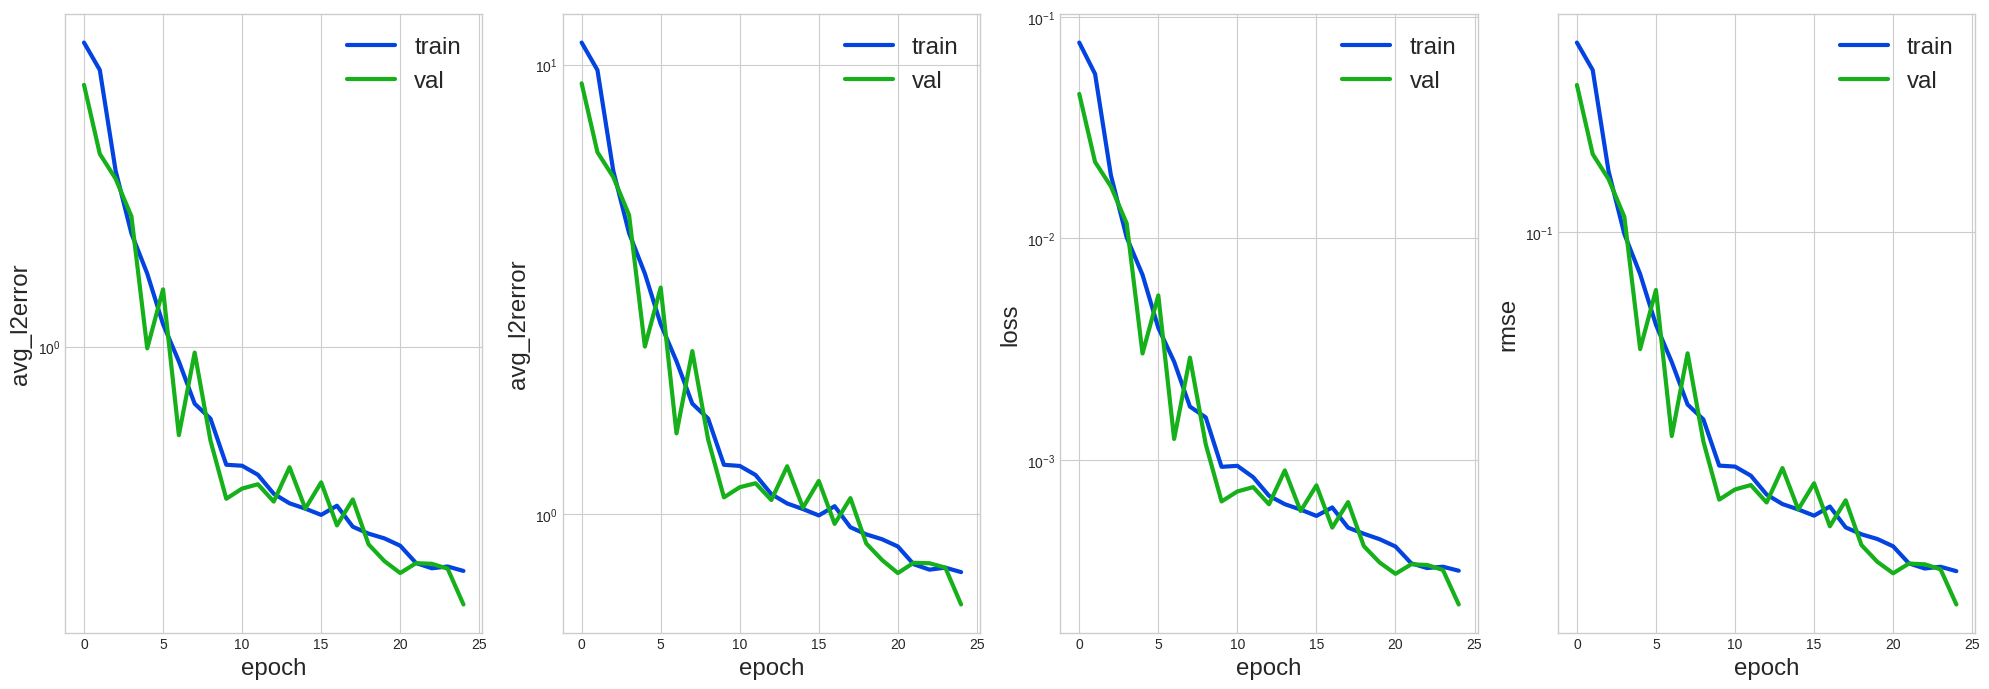

In [35]:
metrics = chonknoris.parse_metrics("%s/%s/csv/metrics.csv"%(save_dir,name))
fig,ax = chonknoris.plot_metrics(metrics,linewidth=LWTHICK,color_train=COLORS[0],color_val=COLORS[1],s0=0)
fig.tight_layout()
metrics.iloc[::max(1,len(metrics)//8)]

In [36]:
mlp_predictor_cls = Predictor(lnn.to(DEVICE), outputs_cls)
Lhat_mlp = mlp_predictor_cls.forward_eval(inputs_cls.inputs_v)
print("l2 relative error: %.2e"%(compute_l2errors(outputs_cls.L_v,Lhat_mlp).mean()))

l2 relative error: 6.28e-01


## GPR

In [226]:
import gc
gc.collect()
torch.cuda.empty_cache()
sgp = fastgps.StandardGP(
    1+Nx*Nx+Ns*Nt*Nx,
    data={"x":inputs_cls.inputs_t,"y":outputs_cls.outputs_t.T},
    shape_batch=[Nx*Nx*(1+Nx*Nx)//2],
    device=DEVICE,
    #shape_scale = [Nx*Nx*(1+Nx*Nx)//2,1],
    lengthscales=1+Nx*Nx+Ns*Nt*Nx,
    #shape_lengthscales=[1],
    shape_lengthscales=[1+Nx*Nx+Ns*Nt*Nx],
    noise = 1e-8,
    requires_grad_noise=True,
    compile_dist_func=True,
    kernel_class="matern52",
    # tfs_scale = (lambda x: torch.log(x-EPS64), lambda x: torch.exp(x)+EPS64),
    # tfs_lengthscales = (lambda x: torch.log(x-EPS64), lambda x: torch.exp(x)+EPS64),
    # tfs_noise = (lambda x: torch.log(x-EPS64), lambda x: torch.exp(x)+EPS64),
    # tfs_scale = (lambda x: torch.sqrt(x-EPS64), lambda x: x**2+EPS64),
    # tfs_lengthscales = (lambda x: torch.sqrt(x-EPS64), lambda x: x**2+EPS64),
    # tfs_noise = (lambda x: torch.sqrt(x-EPS64), lambda x: x**2+EPS64),
    # tfs_scale = (lambda x: (x-EPS64)**(1/4), lambda x: x**4+EPS64),
    # tfs_lengthscales = (lambda x: (x-EPS64)**(1/4), lambda x: x**4+EPS64),
    # tfs_noise = (lambda x: (x-EPS64)**(1/4), lambda x: x**4+EPS64),
)
for pname,pval in sgp.named_parameters():
    print("%s.shape = %s"%(pname,str(tuple(pval.shape))))
print()
fit_data_sgp = sgp.fit(
    loss_metric = "CV",
    cv_weights = 1/torch.linalg.norm(outputs_cls.L_t,dim=(1,2)),
    #cv_weights = torch.log10(1/relaxations_t[updated_t]).to(DEVICE)**4,
    # cv_weights = torch.log10(relaxations_t[updated_t].to(DEVICE))/torch.linalg.norm(outputs_t.to(DEVICE),dim=1),
    iterations = 75,
    verbose = 1,
    store_hists = True,
    stop_crit_wait_iterations = np.inf,
    #stop_crit_improvement_threshold = 1e-1,
    #lr = 1e0,
    #optimizer=torch.optim.Rprop(sgp.parameters(),lr=1e0),#,etas=(0.5,1.2),step_sizes=(0,10)),
    #optimizer=torch.optim.Adam(sgp.parameters(),lr=1e0,amsgrad=True),#,lr=5e-2),
    )

     iter of 2.5e+01 | loss       | term1      | term2     
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
            0.00e+00 | 2.52e+02   | nan        | nan       
            1.00e+00 | 2.52e+02   | nan        | nan       
            2.00e+00 | 2.52e+02   | nan        | nan       
            3.00e+00 | 2.51e+02   | nan        | nan       
            4.00e+00 | 2.50e+02   | nan        | nan       
            5.00e+00 | 2.50e+02   | nan        | nan       
            6.00e+00 | 2.50e+02   | nan        | nan       
            7.00e+00 | 2.50e+02   | nan        | nan       
            8.00e+00 | 2.50e+02   | nan        | nan       
            9.00e+00 | 2.50e+02   | nan        | nan       
            1.00e+01 | 2.50e+02   | nan        | nan       
            1.10e+01 | 2.50e+02   | nan        | nan       
            1.20e+01 | 2.49e+02   | nan        | nan       
            1.30e+01 | 2.49e+02   | nan        | nan       
            1.40e+01 | 2.50e+02   | nan 

dict_keys(['iterations', 'loss_hist', 'scale_hist', 'lengthscales_hist', 'noise_hist', 'task_kernel_hist'])


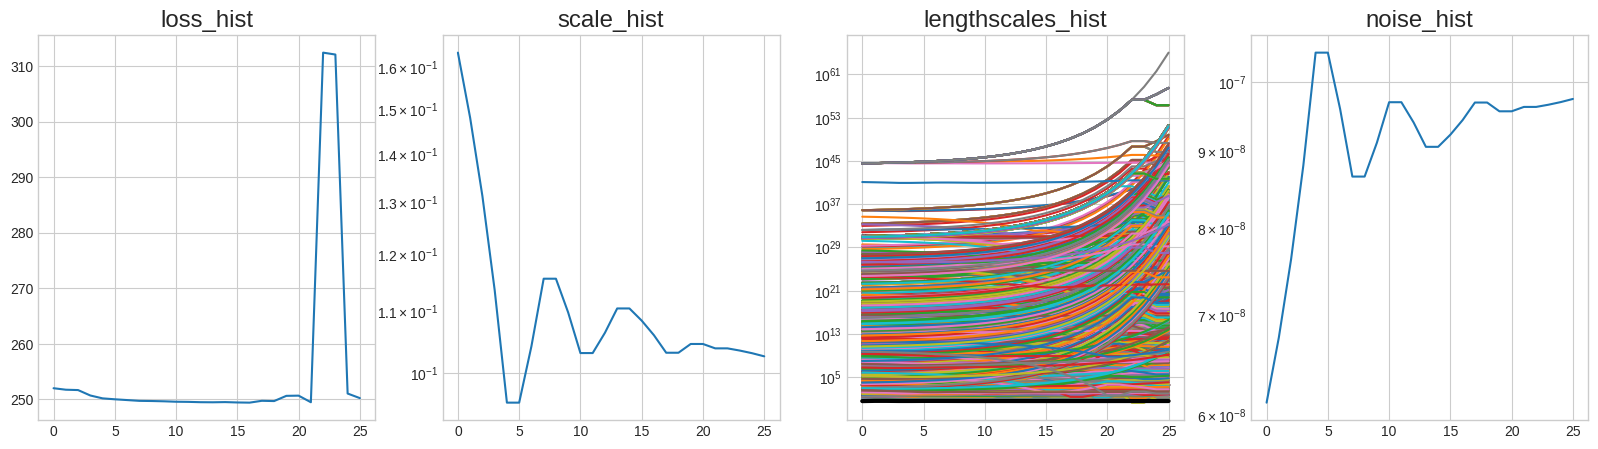

In [227]:
print(fit_data_sgp.keys())
keys_to_plot_log10ed = [
    ('loss_hist',False),
    ('scale_hist',True),
    ('lengthscales_hist',True),
    ('noise_hist',True)]
ncols = len(keys_to_plot_log10ed)
fig,ax = pyplot.subplots(nrows=1,ncols=ncols,figsize=(5*ncols,5))
for i,(key,log10ed) in enumerate(keys_to_plot_log10ed):
    ax[i].plot(torch.arange(fit_data_sgp[key].size(0)),fit_data_sgp[key])
    ax[i].set_title(key,fontsize="xx-large")
    if log10ed: ax[i].set_yscale('log',base=10)
ax[2].plot(torch.arange(fit_data_sgp["lengthscales_hist"].size(0)),fit_data_sgp["lengthscales_hist"][:,0],color="k",linewidth=3);

In [228]:
gp_predictor_cls = Predictor(lambda inputs: sgp.post_mean(inputs).T, outputs_cls)
Lhat_gp = gp_predictor_cls.forward_eval(inputs_cls.inputs_v)
print("l2 relative error: %.2e"%(compute_l2errors(outputs_cls.L_v,Lhat_gp).mean()))

l2 relative error: 3.89e-02


## Inference

In [230]:
class InferenceMachine:
    def __init__(self, predictor, inputs_cls):
        self.predictor = predictor 
        self.inputs_cls = inputs_cls
    def predict(self, relaxations, v, w, JtF):
        inputs = self.inputs_cls.forwards(relaxations, v, w)
        Lhat = self.predictor.forward_eval(inputs)
        success = torch.ones(relaxations.size(0),dtype=bool,device=relaxations.device)
        delta_try = torch.cholesky_solve(JtF[success,:,None],Lhat[success],upper=False)[...,0]
        return delta_try,success
R_infer = 25
vref = data["velocity"][data["vidxs"]][:R_infer].to(DEVICE)
w = data["wavefield"][data["vidxs"]][:R_infer].to(DEVICE)
# v0 = data["vs"][data["vidxs"]][:R_infer,0].to(DEVICE)
# v0 = data["vs"][data["vidxs"]][:R_infer,10].to(DEVICE)
v0 = vhat_ig_gp[:R_infer]
_,data_infer = fwi_gn_solver(p,w,v0,Thetainv_v=Thetainv_v.to(DEVICE),Thetainv_w=Thetainv_w.to(DEVICE),vref=vref,
                             predict=InferenceMachine(gp_predictor_cls, inputs_cls).predict,
                             num_newton_iter=500,
                             relaxation=1e1,
                             lr=1,
                             wiggle_factors_relaxation=(1/2,2),
                             wiggle_factors_lr=(1/2,2),
                             range_relaxations=(0,np.inf),
                             range_lrs = (0,np.inf),
                             print_rmse_flow=False,
                             )


    iter of 500    | time      | RMSE                                                             | L2 relative error                                   | relaxations                                         | lrs                                                 |
                   |           | 5%           median       mean         95%          finite %     | 5%           median       mean         95%          | 5%           median       mean         95%          | 5%           median       mean         95%          |
    -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    0              | 2.29e+01  | 2.31e+00     5.43e+00     5.89e+00     1.21e+01     100.0        | 3.25e-02     4.92e-02     5.10e-02     6.88e-02     | 1.00e+01     1.00e+01     1.00e+01     1.00e+01     | 1.00e+

/home/aleksei.sorokin/DeepNewtonOperator/chonknoris/plots.py:100: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i,j].legend(frameon=False,fontsize="xx-large")


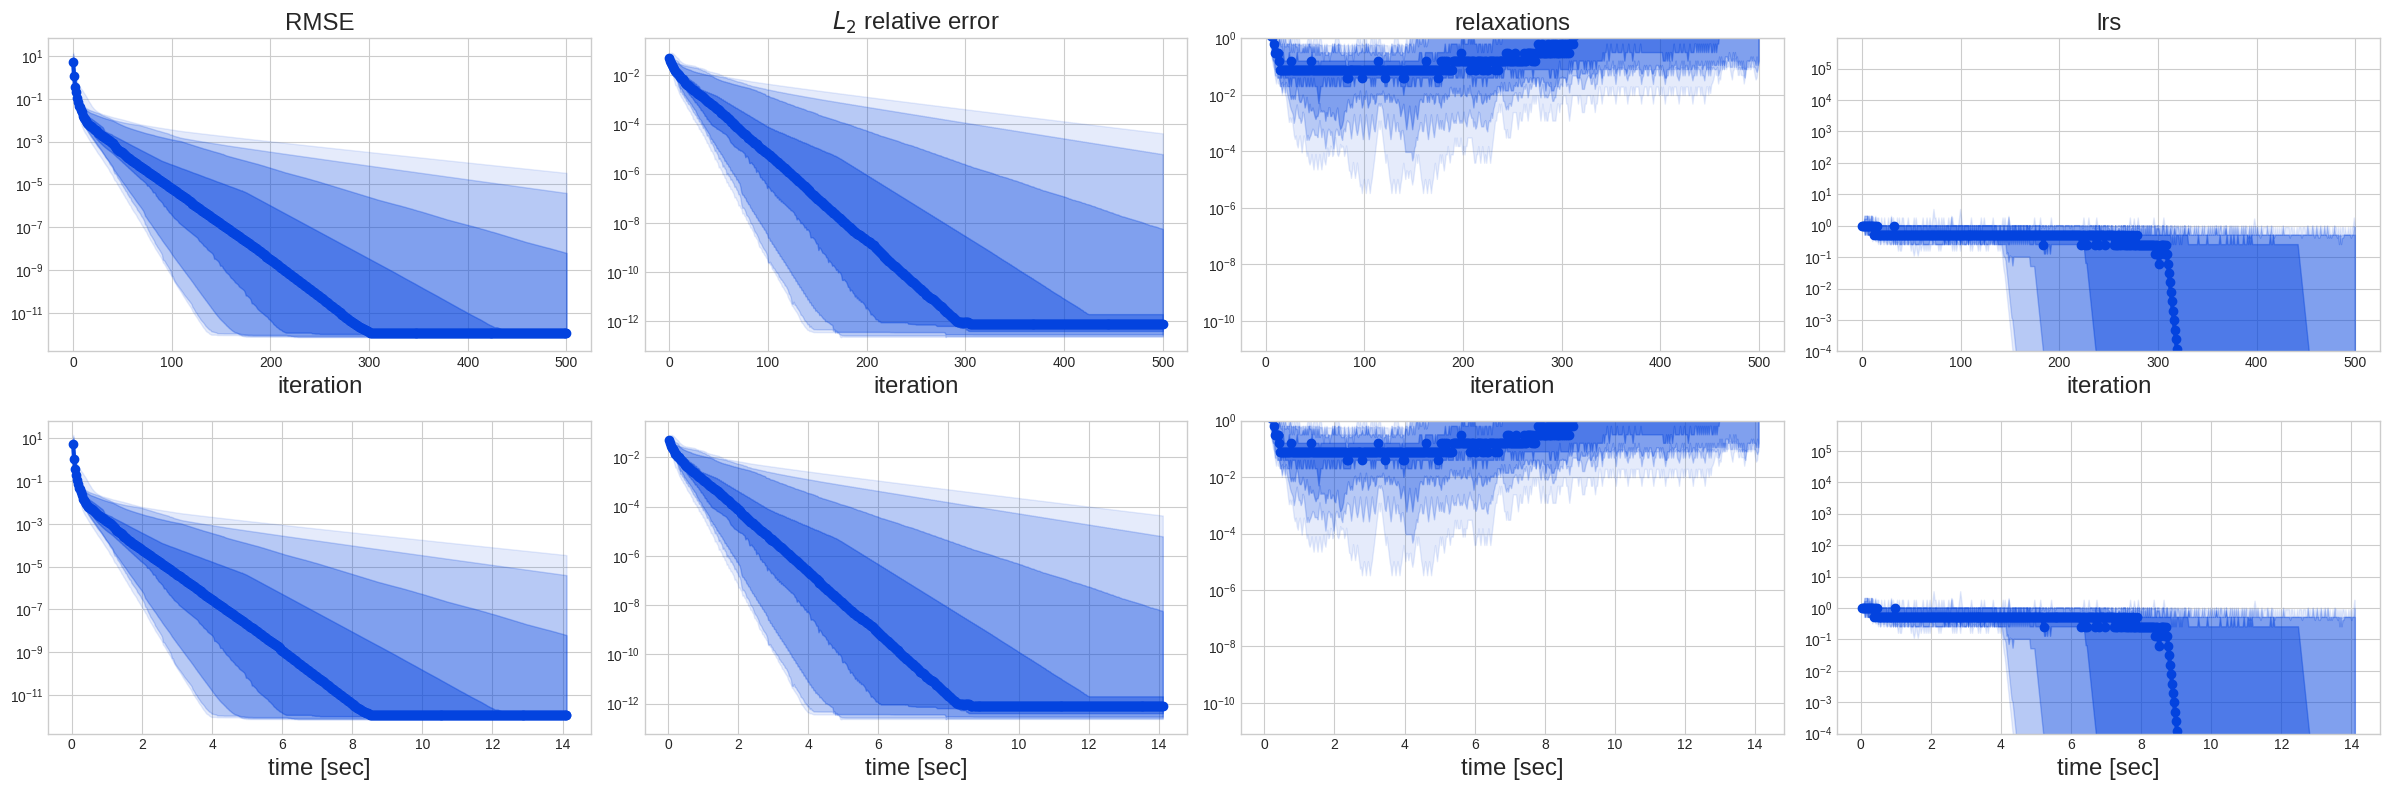

In [231]:
nnif = data_infer["rmses"].size(1) 
fig,ax = chonknoris.plot_band_strand(
    data = [
        [
            [
                #(None,data["rmses"][data["vidxs"]][:R_infer,:nnif],None),
                (None,data_infer["rmses"],None)
            ],
            [
                #(None,data["l2rerrors"][data["vidxs"]][:R_infer,:nnif],None),
                (None,data_infer["l2rerrors"],None)],
            [
                #(None,data["relaxations"][data["vidxs"]][:R_infer,:nnif],None),
                (None,data_infer["relaxations"],None)],
            [
                #(None,data["lrs"][data["vidxs"]][:R_infer,:nnif],None),
                (None,data_infer["lrs"],None)],

        ],
        [
            [
                #(data["times"][:nnif].cumsum(0),data["rmses"][data["vidxs"]][:R_infer,:nnif],None),
                ((data_infer["times"]/R_infer).cumsum(0),data_infer["rmses"],None)],
            [
                #(data["times"][:nnif].cumsum(0),data["l2rerrors"][data["vidxs"]][:R_infer,:nnif],None),
                ((data_infer["times"]/R_infer).cumsum(0),data_infer["l2rerrors"],None)],
            [
                #(data["times"][:nnif].cumsum(0),data["relaxations"][data["vidxs"]][:R_infer,:nnif],None),
                ((data_infer["times"]/R_infer).cumsum(0),data_infer["relaxations"],None)],
            [
                #(data["times"][:nnif].cumsum(0),data["lrs"][data["vidxs"]][:R_infer,:nnif],None),
                ((data_infer["times"]/R_infer).cumsum(0),data_infer["lrs"],None)],

        ],
    ],
    sharex = False,
    titles = [["RMSE",r"$L_2$ relative error","relaxations","lrs"],[None,None,None,None]],
    xlabels = [["iteration"],["time [sec]"]],
    xlogscale = False,
    colors = COLORS,
    ylogscale = True,
    fsx=4,fsy=6)
for i in range(2):
    ax[i,2].set_ylim([ax[i,2].get_ylim()[0],1])
    ax[i,3].set_ylim([1e-4,ax[i,3].get_ylim()[1]])
fig.tight_layout()

tensor([0.0510, 0.0663, 0.0605, 0.0441, 0.0586])
tensor([3.2034e-11, 9.2261e-09, 7.8065e-13, 4.0961e-13, 4.9551e-12])


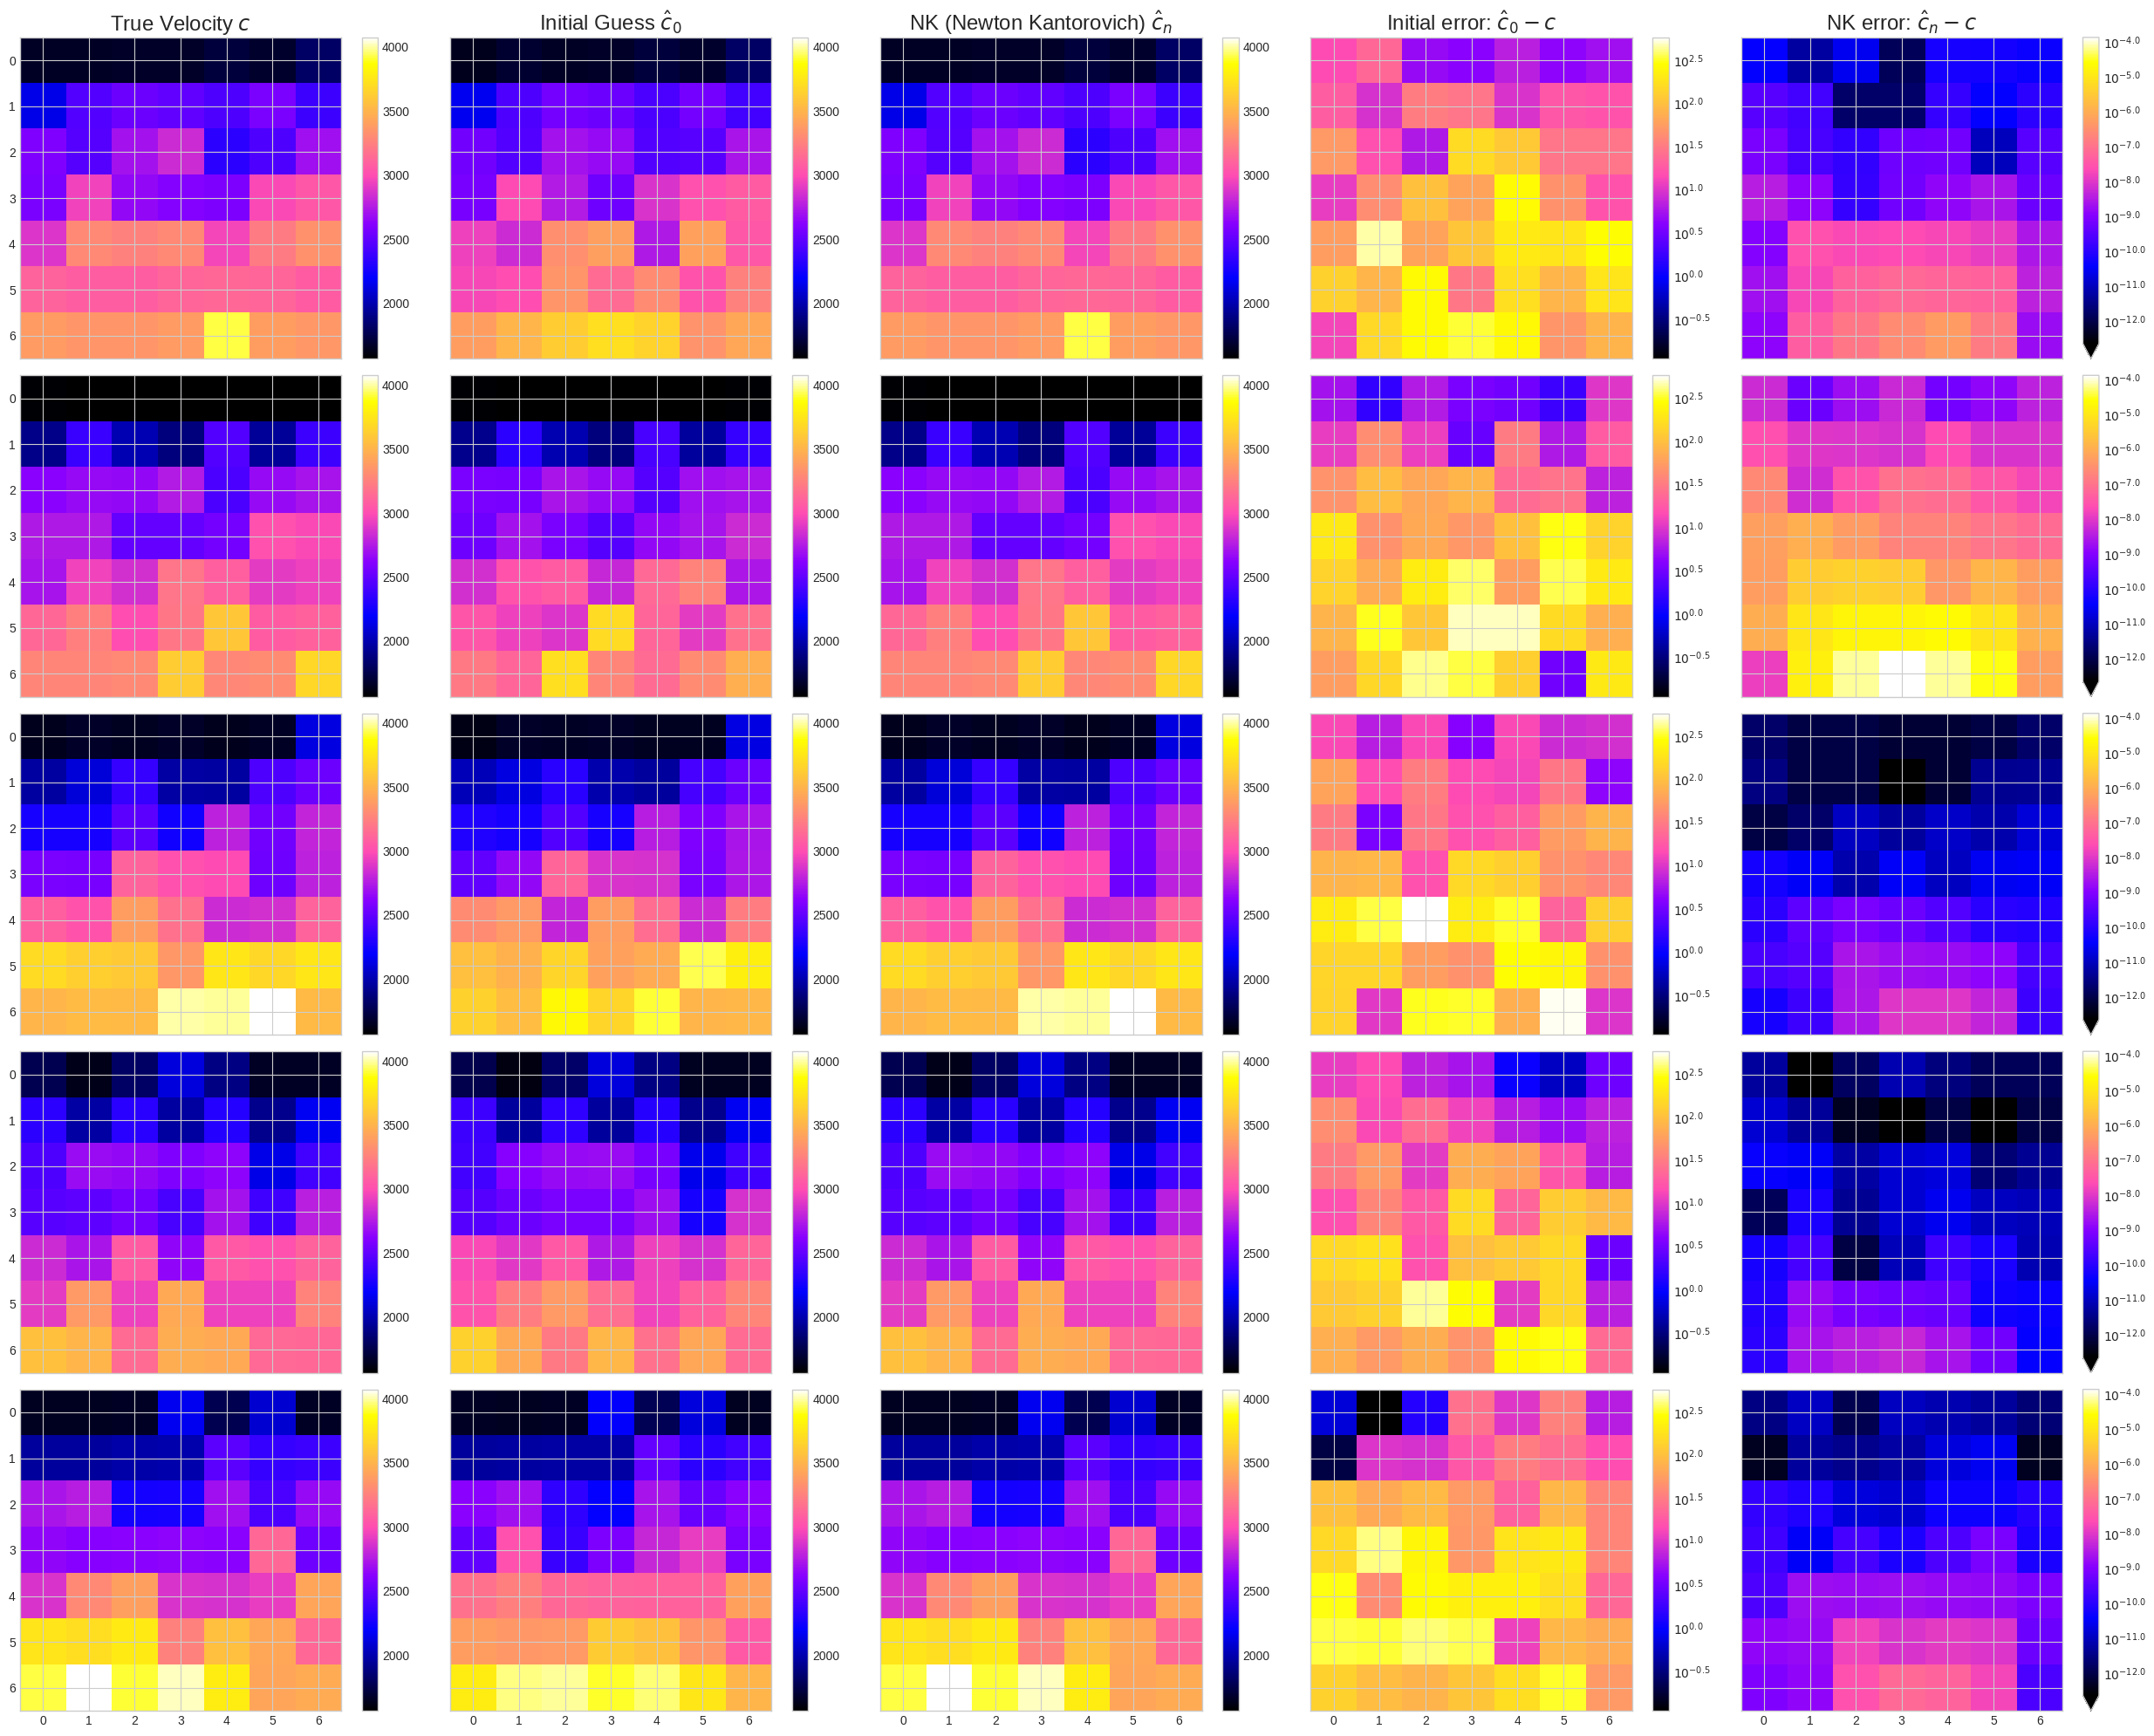

In [232]:
Rplt = 5
print(data_infer["l2rerrors"][:Rplt,0])
print(data_infer["l2rerrors"][:Rplt,-1])
plot_nk_velocities(vref.cpu()[:Rplt],data_infer["vs"][:Rplt,0].cpu(),data_infer["vs"][:Rplt,-1].cpu());

## Check for improved condition numbers

Appears that $\kappa(A) = \kappa(LL^T) =\kappa(L)^2$, but I only see this proven for the *pivoted* Cholesky decomp in https://eprints.maths.manchester.ac.uk/695/1/high87t.pdf (discussion after equation (1.4)) 

In [233]:
L_full = torch.cat([outputs_cls.L_t,outputs_cls.L_v],dim=0)
L_full.shape
Theta_full = torch.einsum("...ij,...kj->...ik",L_full,L_full)
conds_L_full = torch.linalg.cond(L_full)
conds_Theta_full = torch.linalg.cond(Theta_full)
torch.allclose(conds_Theta_full,conds_L_full**2)

True

In [234]:
inputs_all = torch.cat([inputs_cls.inputs_v,inputs_cls.inputs_t],dim=0)
Lhat_gp_full = gp_predictor_cls.forward_eval(inputs_all)
conds_Lhat_gp_full = torch.linalg.cond(Lhat_gp_full)
L2_full = torch.linalg.solve_triangular(Lhat_gp_full,L_full,upper=False)
conds_L2_full = torch.linalg.cond(L2_full)

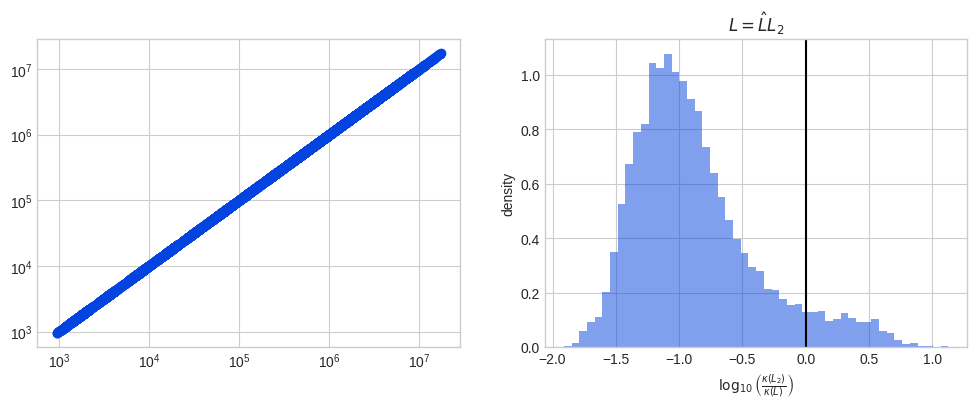

In [236]:
fig,ax = pyplot.subplots(nrows=1,ncols=2,figsize=(12,4))
ax[0].scatter(conds_Theta_full.flatten().cpu(),conds_L_full.flatten().cpu()**2,color=COLORS[0])
ax[0].set_yscale('log')
ax[0].set_xscale('log')
ax[1].hist(torch.log10(conds_L2_full/conds_L_full).flatten().cpu(),alpha=.5,bins=50,density=True,color=COLORS[0])
ax[1].axvline(x=0,color="k")
ax[1].set_xlabel(r"$\log_{10}\left(\frac{\kappa(L_2)}{\kappa(L)}\right)$")
ax[1].set_ylabel("density")
ax[1].set_title(r"$L = \hat{L} L_2$");

In [238]:
_n_t = outputs_cls.L_t.size(0) 
_n_v = outputs_cls.L_v.size(0) 
_n_tot = _n_t+_n_v
assert L2_full.size(0)==_n_tot 
outputs_cls_2 = OutputDataTF(
    L = L2_full[:,None,:,:],
    tidxs = torch.arange(_n_t,device=DEVICE),
    vidxs = torch.arange(_n_t,_n_tot,device=DEVICE),
    updated = torch.ones((_n_tot,1),dtype=bool,device=DEVICE),
    Midxs = torch.arange(1,device=DEVICE),
    normalize = True, 
    log_diag = True,
)
print("outputs_cls_2.outputs_t.shape = %s"%str(tuple(outputs_cls_2.outputs_t.shape)))
print("outputs_cls_2.outputs_v.shape = %s"%str(tuple(outputs_cls_2.outputs_v.shape)))

outputs_cls_2.outputs_t.shape = (7034, 1225)
outputs_cls_2.outputs_v.shape = (1769, 1225)


In [257]:
# import gc
# gc.collect()
# torch.cuda.empty_cache()
# sgp2 = fastgps.StandardGP(
#     1+Nx*Nx+Ns*Nt*Nx,
#     data={"x":inputs_cls.inputs_t,"y":outputs_cls_2.outputs_t.T},
#     shape_batch=[Nx*Nx*(1+Nx*Nx)//2],
#     device=DEVICE,
#     #shape_scale = [Nx*Nx*(1+Nx*Nx)//2,1],
#     lengthscales=1+Nx*Nx+Ns*Nt*Nx,
#     #shape_lengthscales=[1],
#     shape_lengthscales=[1+Nx*Nx+Ns*Nt*Nx],
#     noise = 1e-8,
#     requires_grad_noise=False,
#     compile_dist_func=True,
#     kernel_class="matern12",
#     # tfs_scale = (lambda x: torch.log(x-EPS64), lambda x: torch.exp(x)+EPS64),
#     # tfs_lengthscales = (lambda x: torch.log(x-EPS64), lambda x: torch.exp(x)+EPS64),
#     # tfs_noise = (lambda x: torch.log(x-EPS64), lambda x: torch.exp(x)+EPS64),
#     # tfs_scale = (lambda x: torch.sqrt(x-EPS64), lambda x: x**2+EPS64),
#     # tfs_lengthscales = (lambda x: torch.sqrt(x-EPS64), lambda x: x**2+EPS64),
#     # tfs_noise = (lambda x: torch.sqrt(x-EPS64), lambda x: x**2+EPS64),
#     # tfs_scale = (lambda x: (x-EPS64)**(1/4), lambda x: x**4+EPS64),
#     # tfs_lengthscales = (lambda x: (x-EPS64)**(1/4), lambda x: x**4+EPS64),
#     # tfs_noise = (lambda x: (x-EPS64)**(1/4), lambda x: x**4+EPS64),
# )
# for pname,pval in sgp.named_parameters():
#     print("%s.shape = %s"%(pname,str(tuple(pval.shape))))
# print()
fit_data_sgp2 = sgp2.fit(
    loss_metric = "CV",
    #cv_weights = 1/torch.linalg.norm(outputs_cls_2.L_t,dim=(1,2)),
    #cv_weights = torch.log10(1/relaxations_t[updated_t]).to(DEVICE)**4,
    # cv_weights = torch.log10(relaxations_t[updated_t].to(DEVICE))/torch.linalg.norm(outputs_t.to(DEVICE),dim=1),
    iterations = 100,
    verbose = 1,
    store_hists = True,
    stop_crit_wait_iterations = np.inf,
    #stop_crit_improvement_threshold = 1e-1,
    #lr = 1e0,
    #optimizer=torch.optim.Rprop(sgp2.parameters(),lr=1e0),#,etas=(0.5,1.2),step_sizes=(0,10)),
    #optimizer=torch.optim.Adam(sgp2.parameters(),lr=1e0,amsgrad=True),#,lr=5e-2),
    )

     iter of 1.0e+02 | loss       | term1      | term2     
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
            0.00e+00 | 2.41e+06   | nan        | nan       
            1.00e+00 | 2.41e+06   | nan        | nan       
            2.00e+00 | 2.41e+06   | nan        | nan       
            3.00e+00 | 2.41e+06   | nan        | nan       
            4.00e+00 | 2.41e+06   | nan        | nan       
            5.00e+00 | 2.41e+06   | nan        | nan       
            6.00e+00 | 2.41e+06   | nan        | nan       
            7.00e+00 | 2.41e+06   | nan        | nan       
            8.00e+00 | 2.41e+06   | nan        | nan       
            9.00e+00 | 2.41e+06   | nan        | nan       
            1.00e+01 | 2.41e+06   | nan        | nan       
            1.10e+01 | 2.41e+06   | nan        | nan       
            1.20e+01 | 2.41e+06   | nan        | nan       
            1.30e+01 | 2.41e+06   | nan        | nan       
            1.40e+01 | 2.41e+06   | nan 

KeyboardInterrupt: 

dict_keys(['iterations', 'loss_hist', 'scale_hist', 'lengthscales_hist', 'noise_hist', 'task_kernel_hist'])


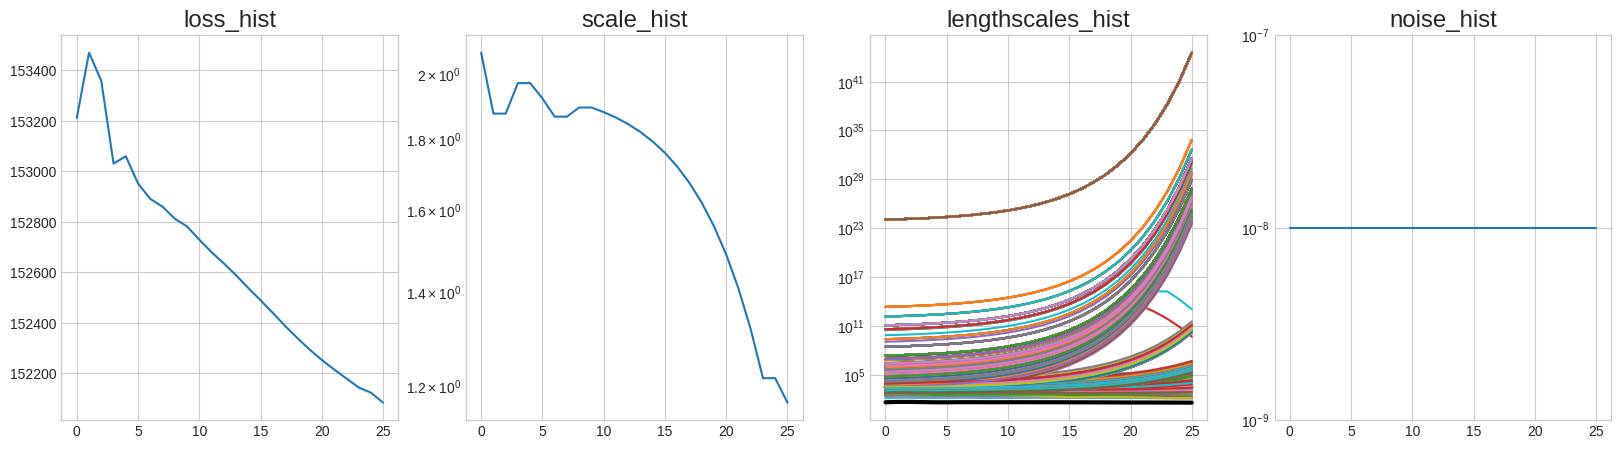

In [258]:
print(fit_data_sgp2.keys())
keys_to_plot_log10ed = [
    ('loss_hist',False),
    ('scale_hist',True),
    ('lengthscales_hist',True),
    ('noise_hist',True)]
ncols = len(keys_to_plot_log10ed)
fig,ax = pyplot.subplots(nrows=1,ncols=ncols,figsize=(5*ncols,5))
for i,(key,log10ed) in enumerate(keys_to_plot_log10ed):
    ax[i].plot(torch.arange(fit_data_sgp2[key].size(0)),fit_data_sgp2[key])
    ax[i].set_title(key,fontsize="xx-large")
    if log10ed: ax[i].set_yscale('log',base=10)
ax[2].plot(torch.arange(fit_data_sgp2["lengthscales_hist"].size(0)),fit_data_sgp2["lengthscales_hist"][:,0],color="k",linewidth=3);

In [259]:
gp_predictor_cls_2 = Predictor(lambda inputs: sgp2.post_mean(inputs).T, outputs_cls_2)
L2hat_gp = gp_predictor_cls_2.forward_eval(inputs_cls.inputs_v)
print("l2 relative error: %.2e"%(compute_l2errors(outputs_cls_2.L_v,L2hat_gp).mean()))

l2 relative error: 8.65e-01


In [260]:
Lhat2_gp_full = gp_predictor_cls_2.forward_eval(inputs_all)

In [261]:
L3_full = torch.linalg.solve_triangular(Lhat2_gp_full,L2_full,upper=False)
conds_L3_full = torch.linalg.cond(L3_full)

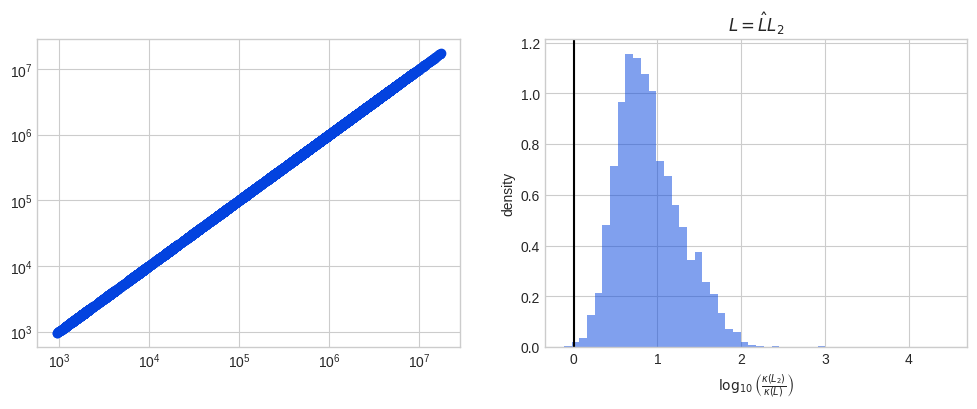

In [262]:
fig,ax = pyplot.subplots(nrows=1,ncols=2,figsize=(12,4))
ax[0].scatter(conds_Theta_full.flatten().cpu(),conds_L_full.flatten().cpu()**2,color=COLORS[0])
ax[0].set_yscale('log')
ax[0].set_xscale('log')
ax[1].hist(torch.log10(conds_L3_full/conds_L2_full).flatten().cpu(),alpha=.5,bins=50,density=True,color=COLORS[0])
ax[1].axvline(x=0,color="k")
ax[1].set_xlabel(r"$\log_{10}\left(\frac{\kappa(L_2)}{\kappa(L)}\right)$")
ax[1].set_ylabel("density")
ax[1].set_title(r"$L = \hat{L} L_2$");

In [264]:
class InferenceMachine2:
    def __init__(self, predictor, predictor2, inputs_cls):
        self.predictor = predictor 
        self.predictor2 = predictor2 
        self.inputs_cls = inputs_cls
    def predict(self, relaxations, v, w, JtF):
        inputs = self.inputs_cls.forwards(relaxations, v, w)
        Lhat1 = self.predictor.forward_eval(inputs)
        Lhat2 = self.predictor2.forward_eval(inputs)
        #Lhat2 = eyeNx2#torch.eye(Lhat1.shape[-1],device=Lhat1.device)
        # (Lhat1@Lhat2)@(Lhat2.T@Lhat1.T) x = y 
        x1 = torch.linalg.solve_triangular(Lhat1,JtF[...,None],upper=False)[...,0] # Lhat2@Lhat2.T@Lhat1.T x = x1
        x2 = torch.linalg.solve_triangular(Lhat2,x1[...,None],upper=False)[...,0] # Lhat2.T@Lhat1.T x = x2
        x3 = torch.linalg.solve_triangular(Lhat2.transpose(dim0=-2,dim1=-1),x2[...,None],upper=True)[...,0] # Lhat1.T x = x3
        x = torch.linalg.solve_triangular(Lhat1.transpose(dim0=-2,dim1=-1),x3[...,None],upper=True)[...,0]
        success = torch.ones(relaxations.size(0),dtype=bool,device=relaxations.device)
        return x,success
R_infer = 10
vref = data["velocity"][data["vidxs"]][:R_infer].to(DEVICE)
w = data["wavefield"][data["vidxs"]][:R_infer].to(DEVICE)
v0 = data["vs"][data["vidxs"]][:R_infer,0].to(DEVICE)
#v0 = data["vs"][data["vidxs"]][:R_infer,10].to(DEVICE)
# v0 = vhat_ig_gp[:R_infer]
_,data_infer_2 = fwi_gn_solver(p,w,v0,Thetainv_v=Thetainv_v.to(DEVICE),Thetainv_w=Thetainv_w.to(DEVICE),vref=vref,
                             predict=InferenceMachine2(gp_predictor_cls, gp_predictor_cls_2, inputs_cls).predict,
                             num_newton_iter=50,
                             relaxation=1e1,
                             lr=1,
                             wiggle_factors_relaxation=(1/2,2),
                             wiggle_factors_lr=(1/2,2),
                             range_relaxations=(0,np.inf),
                             range_lrs = (0,np.inf),
                             print_rmse_flow=False,
                             )


    iter of 50     | time      | RMSE                                                             | L2 relative error                                   | relaxations                                         | lrs                                                 |
                   |           | 5%           median       mean         95%          finite %     | 5%           median       mean         95%          | 5%           median       mean         95%          | 5%           median       mean         95%          |
    -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    0              | 8.69e+00  | 4.25e+01     5.15e+01     5.58e+01     7.92e+01     100.0        | 7.21e-02     7.95e-02     8.18e-02     9.52e-02     | 1.00e+01     1.00e+01     1.00e+01     1.00e+01     | 1.00e+

KeyboardInterrupt: 

/home/aleksei.sorokin/DeepNewtonOperator/chonknoris/plots.py:100: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i,j].legend(frameon=False,fontsize="xx-large")


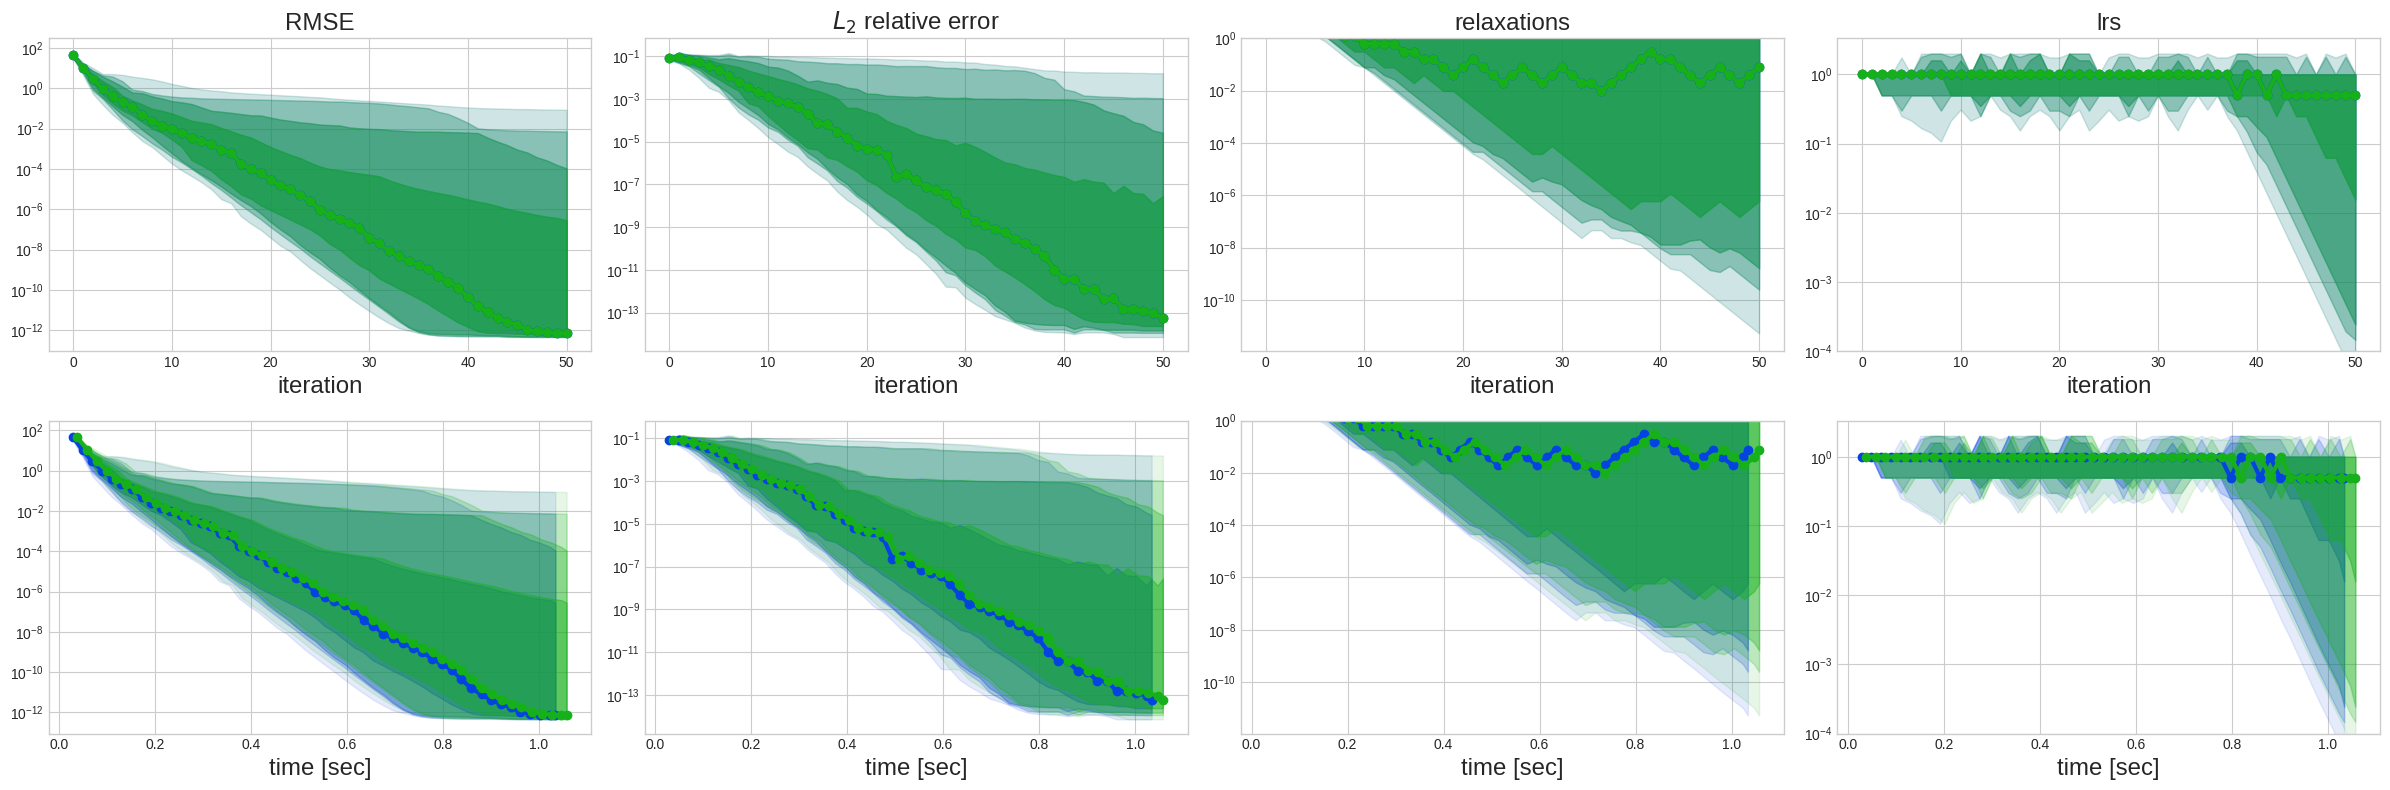

In [122]:
nnif = data_infer["rmses"].size(1) 
fig,ax = chonknoris.plot_band_strand(
    data = [
        [
            [
                #(None,data["rmses"][data["vidxs"]][:R_infer,:nnif],None),
                (None,data_infer["rmses"],None),
                (None,data_infer_2["rmses"],None)
            ],
            [
                #(None,data["l2rerrors"][data["vidxs"]][:R_infer,:nnif],None),
                (None,data_infer["l2rerrors"],None),
                (None,data_infer_2["l2rerrors"],None)
            ],
            [
                #(None,data["relaxations"][data["vidxs"]][:R_infer,:nnif],None),
                (None,data_infer["relaxations"],None),
                (None,data_infer_2["relaxations"],None)
            ],
            [
                #(None,data["lrs"][data["vidxs"]][:R_infer,:nnif],None),
                (None,data_infer["lrs"],None),
                (None,data_infer_2["lrs"],None),
            ]

        ],
        [
            [
                #(data["times"][:nnif].cumsum(0),data["rmses"][data["vidxs"]][:R_infer,:nnif],None),
                ((data_infer["times"]/R_infer).cumsum(0),data_infer["rmses"],None),
                ((data_infer_2["times"]/R_infer).cumsum(0),data_infer_2["rmses"],None),
            ],
            [
                #(data["times"][:nnif].cumsum(0),data["l2rerrors"][data["vidxs"]][:R_infer,:nnif],None),
                ((data_infer["times"]/R_infer).cumsum(0),data_infer["l2rerrors"],None),
                ((data_infer_2["times"]/R_infer).cumsum(0),data_infer_2["l2rerrors"],None),
            ],
            [
                #(data["times"][:nnif].cumsum(0),data["relaxations"][data["vidxs"]][:R_infer,:nnif],None),
                ((data_infer["times"]/R_infer).cumsum(0),data_infer["relaxations"],None),
                ((data_infer_2["times"]/R_infer).cumsum(0),data_infer_2["relaxations"],None),
            ],
            [
                #(data["times"][:nnif].cumsum(0),data["lrs"][data["vidxs"]][:R_infer,:nnif],None),
                ((data_infer["times"]/R_infer).cumsum(0),data_infer["lrs"],None),
                ((data_infer_2["times"]/R_infer).cumsum(0),data_infer_2["lrs"],None),
            ],

        ],
    ],
    sharex = False,
    titles = [["RMSE",r"$L_2$ relative error","relaxations","lrs"],[None,None,None,None]],
    xlabels = [["iteration"],["time [sec]"]],
    xlogscale = False,
    colors = COLORS,
    ylogscale = True,
    fsx=4,fsy=6)
for i in range(2):
    ax[i,2].set_ylim([ax[i,2].get_ylim()[0],1])
    ax[i,3].set_ylim([1e-4,ax[i,3].get_ylim()[1]])
fig.tight_layout()